### This notebook provides a quick overview to test the population distributions and the processing steps, comparing **GWTC-4.0 FullPop-4.0** against the newer **GWTC-5.0 FullPop** (and, where noted, GWTC-3.0 Power Law + Dip + Break).

Equation (B24) in the [GWTC-4 paper](https://arxiv.org/abs/2508.18083) is used to draw from the *FullPop-4.0* model, which is an update of the **Broken Power Law + Dip** model introduced by [Farah et al. (2022)](https://iopscience.iop.org/article/10.3847/1538-4357/ac5f03) and used in [GWTC-3](https://journals.aps.org/prx/abstract/10.1103/PhysRevX.13.011048). The GWTC-5.0 population paper (App. B.2) states its `FullPop` model "is the same as the FULLPOP-4.0 model described in Abac et al." -- same equations below, only the fitted hyperparameter *values* differ between the two releases.


### Model Description: FullPop (GWTC-4.0 "FullPop-4.0" / GWTC-5.0 "FullPop")

We model the **1D mass distribution** of compact objects using the *FullPop* functional form, common to GWTC-4.0 and GWTC-5.0 -- only the hyperparameter values (`mu1`, `NSmax`, ... loaded below) change between the two releases.  
This captures the **lower and upper mass gaps** as well as localized **overdensities** in the population [GWTC-4 paper](https://arxiv.org/abs/2508.18083), the equation Equation (B7)


The probability density is:


\begin{equation}
p(m | \lambda) \propto \frac{\displaystyle\left[1 + \sum_{i=1}^{2} c_i G_i(m)\right] \times S(m) \times \prod_{i=1}^{2} n_i(m)}{h(m) \times l(m)}
\end{equation}
where $G_i(m) = N(\mu_{\mathrm{peak},i}, \sigma_{\mathrm{peak},i})$
are Gaussian peaks truncated over the fixed domain
$[m_{\mathrm{inj,min}}, m_{\mathrm{inj,max}}] = [1, 500]\,M_\odot$, set by the boundaries of the injection campaign and fixed prior to inference, and $c_i$ are the corresponding mixing fractions.

The piecewise power-law component $S(m)$ is defined as:
\begin{equation*}
S(m) = \begin{cases}
m^{\alpha_1} & m < m_{\mathrm{max,NS}} \\[0.3em]
K_1 \, m^{\alpha_{\mathrm{dip}}} & m_{\mathrm{max,NS}} \leq m < m_{\mathrm{min,BH}} \\[0.3em]
K_2 \, m^{\alpha_2} & m \geq m_{\mathrm{min,BH}}
\end{cases}
\end{equation*}
with  

$$
K_1 = m_{\mathrm{max,NS}}^{\alpha_1 - \alpha_{\mathrm{dip}}}, \qquad
K_2 = m_{\mathrm{max,NS}}^{\alpha_1 - \alpha_{\mathrm{dip}}}
       \times m_{\mathrm{min,BH}}^{\alpha_{\mathrm{dip}} - \alpha_2}.
$$



The notch functions suppress the distribution in the mass gaps:
\begin{align*}
n_i(m) = \begin{cases}
n_1(m) &= 1 - \frac{A_1}{\left[1 + \left(\frac{m_{\mathrm{max,NS}}}{m}\right)^{\eta_1}\right]\left[1 + \left(\frac{m}{m_{\mathrm{min,BH}}}\right)^{\eta_2}\right]} \\[2em]
n_2(m) &= 1 - \frac{A_2}{\left[1 + \left(\frac{\gamma_{\mathrm{low},2}}{m}\right)^{\eta_3}\right]\left[1 + \left(\frac{m}{\gamma_{\mathrm{high},2}}\right)^{\eta_4}\right]}
\end{cases}
\end{align*}

The tapering functions smoothly suppress the distribution near the low-mass and high-mass boundaries:
\begin{align*}
h(m) &= 1 + \left(\frac{m_{\mathrm{min,NS}}}{m}\right)^{\eta_0}, \\
l(m) &= 1 + \left(\frac{m}{m_{\mathrm{max,BH}}}\right)^{\eta_5}.
\end{align*}

### We use a Pairing process


For the 2D mass distribution, the simulated population is generated using a **mass–ratio dependent pairing method**.  
This means that the secondary mass is drawn conditionally on the primary mass, introducing correlations between \( mass_1 \) and \( mass_2 \).

To make a **fair comparison** between the **model** and the **simulated data**, we must include the **pairing effect in the model** as well.  
If we used an independent 2D model, we would ignore these correlations and introduce systematic biases.  
By using the same pairing prescription in the model, we ensure that both the **shape** and the **correlations** of the distributions match.


For the mass distribution with a mass ratio-dependent pairing function (Eq: B14, [GWTC-4 paper](https://arxiv.org/abs/2508.18083)),

<!-- where $p(m1 | \lambda)$ and $p(m2 | \lambda)$ are identical. -->

Fhe 2D mass distribution reads:

\begin{align*}
p(m_1, m_2 \mid \Lambda) \propto p(m_1 \mid \lambda)\, p(m_2 \mid \lambda) \times q^{\beta_i} \times W(m_1, m_2),
\end{align*}

where $q \equiv m_2/m_1$ is the mass ratio. The pairing exponent is defined as:

\begin{align*}
\beta_i =
\begin{cases}
\beta_1, & m_2 < m_{\mathrm{break}}, \\[2em]
\beta_2, & m_2 \geq m_{\mathrm{break}}.
\end{cases}
\end{align*}



The window function $W(m_1, m_2)$ enforces the constraint $m_1 \geq m_2$. **GWTC-5.0** additionally excludes the region $m_1 > 60\,M_\odot$ and $m_2 < 3\,M_\odot$ from the inference itself (no simulated injections there, so selection effects cannot be evaluated self-consistently -- see GWTC-5.0 Fig. 1). **GWTC-4.0 does not apply this exclusion.** The 2D sections below still use GWTC-4.0 only and do not yet apply this cut (see the scope note before the 2D section); it is a TODO once a GWTC-5.0 posterior-predictive sample file is available.


In [232]:
# --- Installation & Setup (Colab only) ---

import sys

# Check if the env run under Colab
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess

    # Remove old clone if exists
    subprocess.run(["rm", "-rf", "cbc-population-distributions"])

    # Clone our GitHub repository into the Colab environment
    !git clone https://github.com/weizmannk/cbc-population-distributions.git
    %cd cbc-population-distributions

    # Install uv (fast dependency manager) and sync dependencies from uv.lock
    !pip install -q uv
    !uv sync

    # (Optional) Add the repo to PYTHONPATH if it's not an installable package

    import glob
    import os

    pyver = f"{sys.version_info.major}.{sys.version_info.minor}"
    venv_site = glob.glob(f".venv/lib/python{pyver}/site-packages")[0]
    sys.path.insert(0, os.path.abspath(venv_site))
    sys.path.insert(0, os.path.abspath("."))
    print("Environment ready. You can now run the rest of the notebook.")

## Importing Libraries

In [233]:
import logging
import os
import shutil
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from astropy.table import Table
from gwpopulation.utils import truncnorm
from IPython.display import Markdown, display
from matplotlib.patches import Rectangle
from matplotlib.patheffects import withStroke
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.integrate import simpson
from scipy.stats import gaussian_kde

if IN_COLAB:
    from scripts.paper_plots.bns_inspiral_range import (
        BNSInspiralRangeCalculator,
    )
    from scripts.paper_plots.kn_detection import plot_results, run_analysis
else:
    # paper_plots/ is a sibling of notebooks/, so scripts/ needs to be on sys.path.
    sys.path.insert(0, "..")
    from paper_plots.bns_inspiral_range import BNSInspiralRangeCalculator
    from paper_plots.kn_detection import plot_results, run_analysis

%matplotlib inline

In [234]:
# ============================================================================
# Logging / warning configuration
# ============================================================================
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logger = logging.getLogger(__name__)

warnings.filterwarnings("ignore", message="No LaTeX-compatible font")
logging.getLogger("matplotlib").setLevel(logging.ERROR)

In [235]:
# ============================================================================
# Matplotlib style
# ============================================================================
USE_LATEX = True if shutil.which("latex") is not None else False

plt.rcParams.update(
    {
        "font.family": "Times New Roman",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "text.usetex": USE_LATEX,
        "font.size": 12,
        "legend.fontsize": 14,
        "axes.labelsize": 12,
        "axes.titlesize": 16,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "savefig.dpi": 300,
    }
)

### ============================================================================
### File Paths Configuration
### ============================================================================

In [236]:
# Paths are relative to scripts/notebooks/, two levels below the repo root.
DATA_DIR: str = "../../data/raw"
DERIVED_DIR: str = "../../data/derived"

#: MAP hyperparameters for GWTC-4.0/5.0, cached by scripts/hyperparams/get_hyperparams.py.
HYPERPARAMS_MAP_CSV: str = os.path.join(DERIVED_DIR, "hyperparams_map.csv")

#: Posterior-median hyperparameters for GWTC-4.0/5.0, same cache script.
#: Matches GWTC-5.0's own convention of reporting medians rather than a
#: single MAP sample.
HYPERPARAMS_MEDIAN_CSV: str = os.path.join(DERIVED_DIR, "hyperparams_median.csv")

#: Posterior-predictive mass samples (columns mass1, mass2) for GWTC-5.0 FullPop.
CBC_MASS_DISTRIBUTION_FILE_GWTC5: str = os.path.join(DATA_DIR, "fullpop_MAP.h5")

### ============================================================================
### Load Population Results and Extract MAP Hyperparameters
### ============================================================================

In [237]:
# Load cached MAP hyperparameters (built by scripts/hyperparams/get_hyperparams.py).
# Set REBUILD_HYPERPARAMS_CACHE=True to rebuild it (downloads from DCC/Zenodo
# if needed); FORCE_REEXTRACT=True also ignores the existing cache.
REBUILD_HYPERPARAMS_CACHE = False
FORCE_REEXTRACT = False

if REBUILD_HYPERPARAMS_CACHE:
    import sys

    sys.path.insert(0, "../hyperparams")
    import get_hyperparams

    get_hyperparams.main(force=FORCE_REEXTRACT)

logger.info("Loading cached MAP hyperparameters from: %s", HYPERPARAMS_MAP_CSV)
hyperparams_map = pd.read_csv(HYPERPARAMS_MAP_CSV, index_col=0)

logger.info("Loading cached median hyperparameters from: %s", HYPERPARAMS_MEDIAN_CSV)
hyperparams_median = pd.read_csv(HYPERPARAMS_MEDIAN_CSV, index_col=0)

hyperparams4 = hyperparams_map.loc["GWTC-4.0 (popsummary)"].dropna()
logger.info(
    "MAP hyperparameters loaded: %s ...", ", ".join(list(hyperparams4.index)[:5])
)

2026-09-03 16:32:52  INFO      Loading cached MAP hyperparameters from: ../../data/derived/hyperparams_map.csv
2026-09-03 16:32:52  INFO      Loading cached median hyperparameters from: ../../data/derived/hyperparams_median.csv
2026-09-03 16:32:52  INFO      MAP hyperparameters loaded: A, A2, BHmax, BHmin, NSmax ...


### ============================================================================
### GWTC-5.0 FullPop -- load MAP hyperparameters and compare key names
### ============================================================================

Before plotting anything, check whether the hyperparameter **names** moved
between GWTC-4.0 and GWTC-5.0. A renamed key raises `AttributeError` inside
`fullpop()` -- safe, loud failure. A **retained key with a changed
definition** would silently produce a plausible but wrong curve, so the
values are compared explicitly below, not just the key sets.

In [238]:
hyperparams5 = hyperparams_map.loc["GWTC-5.0 (popsummary)"].dropna()
logger.info(
    "MAP hyperparameters loaded: %s ...", ", ".join(list(hyperparams5.index)[:5])
)

# -- Key comparison: GWTC-4.0 vs GWTC-5.0 ---------------------------------------
# dropna() restores each catalogue's real keys (the CSV is a union table,
# so a key missing from one side would otherwise show as NaN, not absent).
_k4, _k5 = set(hyperparams4.index), set(hyperparams5.index)
_only_4 = sorted(_k4 - _k5)
_only_5 = sorted(_k5 - _k4)
print(f"Keys only in GWTC-4.0 ({len(_only_4)}):", _only_4)
print(f"Keys only in GWTC-5.0 ({len(_only_5)}):", _only_5)

# Diagnostic ``ln_bf_*`` / ``var_*`` columns are per-event bookkeeping, not
# model hyperparameters -- excluded from the printed table for readability.
print(f"\n{'key':12} {'GWTC-4.0':>12} {'GWTC-5.0':>12}")
for _k in sorted(_k4 & _k5):
    if _k in ("log_likelihood", "log_prior") or _k.startswith(("ln_bf_", "var_")):
        continue
    print(f"{_k:12} {hyperparams4[_k]:12.4f} {hyperparams5[_k]:12.4f}")

2026-09-03 16:32:52  INFO      MAP hyperparameters loaded: A, A2, BHmax, BHmin, NSmax ...


Keys only in GWTC-4.0 (6): ['rate_bbh', 'rate_bh-gap', 'rate_bns', 'rate_full', 'rate_ns-gap', 'rate_nsbh']
Keys only in GWTC-5.0 (196): ['ln_bf_144', 'ln_bf_145', 'ln_bf_146', 'ln_bf_147', 'ln_bf_148', 'ln_bf_149', 'ln_bf_150', 'ln_bf_151', 'ln_bf_152', 'ln_bf_153', 'ln_bf_154', 'ln_bf_155', 'ln_bf_156', 'ln_bf_157', 'ln_bf_158', 'ln_bf_159', 'ln_bf_160', 'ln_bf_161', 'ln_bf_162', 'ln_bf_163', 'ln_bf_164', 'ln_bf_165', 'ln_bf_166', 'ln_bf_167', 'ln_bf_168', 'ln_bf_169', 'ln_bf_170', 'ln_bf_171', 'ln_bf_172', 'ln_bf_173', 'ln_bf_174', 'ln_bf_175', 'ln_bf_176', 'ln_bf_177', 'ln_bf_178', 'ln_bf_179', 'ln_bf_180', 'ln_bf_181', 'ln_bf_182', 'ln_bf_183', 'ln_bf_184', 'ln_bf_185', 'ln_bf_186', 'ln_bf_187', 'ln_bf_188', 'ln_bf_189', 'ln_bf_190', 'ln_bf_191', 'ln_bf_192', 'ln_bf_193', 'ln_bf_194', 'ln_bf_195', 'ln_bf_196', 'ln_bf_197', 'ln_bf_198', 'ln_bf_199', 'ln_bf_200', 'ln_bf_201', 'ln_bf_202', 'ln_bf_203', 'ln_bf_204', 'ln_bf_205', 'ln_bf_206', 'ln_bf_207', 'ln_bf_208', 'ln_bf_209', 'ln_

In [239]:
# ============================================================================
# Population Model Parameters
# ============================================================================

PARAMS_INFO = {
    # Power-law indices
    "alpha_1": r"$\alpha_1$",
    "alpha_2": r"$\alpha_2$",
    "alpha_dip": r"$\alpha_{\mathrm{dip}}$",
    # Mass boundaries
    "NSmin": r"$m_{\mathrm{min,NS}}$",
    "NSmax": r"$m_{\mathrm{max,NS}}$",  # Lower mass gap boundary
    "BHmin": r"$m_{\mathrm{min,BH}}$",  # Upper mass gap boundary
    "BHmax": r"$m_{\mathrm{max,BH}}$",
    # Amplitude parameters
    "A": r"$A_1$",
    "A2": r"$A_2$",
    # Upper mass range (second notch boundaries)
    "UPPERmin": r"$\gamma_{\mathrm{low},2}$",
    "UPPERmax": r"$\gamma_{\mathrm{high},2}$",
    # Gaussian peak parameters
    "mu1": r"$\mu_{\mathrm{peak},1}$",
    "sig1": r"$\sigma_{\mathrm{peak},1}$",
    "mix1": r"$c_1$",
    "mu2": r"$\mu_{\mathrm{peak},2}$",
    "sig2": r"$\sigma_{\mathrm{peak},2}$",
    "mix2": r"$c_2$",
    # Notch & taper exponents
    "n0": r"$\eta_0$",  # low-mass taper  h(m)
    "n1": r"$\eta_1$",  # first notch,  low-side
    "n2": r"$\eta_2$",  # first notch,  high-side
    "n3": r"$\eta_3$",  # second notch, low-side
    "n4": r"$\eta_4$",  # second notch, high-side
    "n5": r"$\eta_5$",  # high-mass taper l(m)
}


# -- Corrected group name -------------------------------------------------------
PARAMS_GROUPS = {
    "Power-law indices": ["alpha_1", "alpha_2", "alpha_dip"],
    "Mass boundaries": ["NSmin", "NSmax", "BHmin", "BHmax"],
    "Amplitude": ["A", "A2"],
    "Upper mass range": ["UPPERmin", "UPPERmax"],
    "Gaussian peaks": ["mu1", "sig1", "mix1", "mu2", "sig2", "mix2"],
    "Low-mass taper": ["n0"],
    "First notch (lower gap)": ["n1", "n2"],
    "Second notch (upper gap)": ["n3", "n4"],
    "High-mass taper": ["n5"],
}

# Sanity check: every key in GROUPS exists in INFO
_missing = [k for keys in PARAMS_GROUPS.values() for k in keys if k not in PARAMS_INFO]
if _missing:
    raise KeyError(f"Keys in PARAMS_GROUPS missing from PARAMS_INFO: {_missing}")

In [240]:
def display_params(params_info: dict, params_groups: dict, hyperparams=None):
    for group, keys in params_groups.items():
        if hyperparams is not None:
            header = f"### {group}\n| Key | Symbol | MAP value |\n|---|:---:|---:|"
            rows = [
                f"| `{k}` | {params_info[k]} | "
                f"{f'{hyperparams[k]:.4f}' if k in hyperparams else '—'} |"
                for k in keys
            ]
        else:
            header = f"### {group}\n| Key | Symbol |\n|---|:---:|"
            rows = [f"| `{k}` | {params_info[k]} |" for k in keys]

        display(Markdown(header + "\n" + "\n".join(rows)))

In [241]:
display_params(PARAMS_INFO, PARAMS_GROUPS, hyperparams=hyperparams5)

### Power-law indices
| Key | Symbol | MAP value |
|---|:---:|---:|
| `alpha_1` | $\alpha_1$ | -4.7561 |
| `alpha_2` | $\alpha_2$ | -1.1990 |
| `alpha_dip` | $\alpha_{\mathrm{dip}}$ | -1.6147 |

### Mass boundaries
| Key | Symbol | MAP value |
|---|:---:|---:|
| `NSmin` | $m_{\mathrm{min,NS}}$ | 1.2526 |
| `NSmax` | $m_{\mathrm{max,NS}}$ | 3.2977 |
| `BHmin` | $m_{\mathrm{min,BH}}$ | 8.8223 |
| `BHmax` | $m_{\mathrm{max,BH}}$ | 146.3027 |

### Amplitude
| Key | Symbol | MAP value |
|---|:---:|---:|
| `A` | $A_1$ | 0.7254 |
| `A2` | $A_2$ | 0.6614 |

### Upper mass range
| Key | Symbol | MAP value |
|---|:---:|---:|
| `UPPERmin` | $\gamma_{\mathrm{low},2}$ | 36.5298 |
| `UPPERmax` | $\gamma_{\mathrm{high},2}$ | 111.3502 |

### Gaussian peaks
| Key | Symbol | MAP value |
|---|:---:|---:|
| `mu1` | $\mu_{\mathrm{peak},1}$ | 38.4926 |
| `sig1` | $\sigma_{\mathrm{peak},1}$ | 16.3233 |
| `mix1` | $c_1$ | 623.2646 |
| `mu2` | $\mu_{\mathrm{peak},2}$ | 8.0169 |
| `sig2` | $\sigma_{\mathrm{peak},2}$ | 1.5726 |
| `mix2` | $c_2$ | 322.2115 |

### Low-mass taper
| Key | Symbol | MAP value |
|---|:---:|---:|
| `n0` | $\eta_0$ | 50.0000 |

### First notch (lower gap)
| Key | Symbol | MAP value |
|---|:---:|---:|
| `n1` | $\eta_1$ | 50.0000 |
| `n2` | $\eta_2$ | 50.0000 |

### Second notch (upper gap)
| Key | Symbol | MAP value |
|---|:---:|---:|
| `n3` | $\eta_3$ | 30.0000 |
| `n4` | $\eta_4$ | 30.0000 |

### High-mass taper
| Key | Symbol | MAP value |
|---|:---:|---:|
| `n5` | $\eta_5$ | 7.2913 |

In [242]:
# ============================================================================
# Load Simulated CBC Mass Distributions
# ============================================================================

logger.info(
    f"Loading CBC samples from: {os.path.basename(CBC_MASS_DISTRIBUTION_FILE_GWTC5)}"
)

try:
    table = Table.read(CBC_MASS_DISTRIBUTION_FILE_GWTC5)
    logger.info(f"Successfully loaded table with {len(table)} rows")
    print(f"Successfully loaded table with {len(table)} rows")

    # Extract mass columns
    m1_samples = table["mass1"]
    m2_samples = table["mass2"]

    sun_mass = r"$M_{\odot}$"
    logger.info(f"Extracted {len(m1_samples):,} CBC mass samples")
    print(f"Extracted {len(m1_samples):,} CBC mass samples")
    logger.info(
        f"  Primary mass (m1): [{m1_samples.min():.2f}, {m1_samples.max():.2f}] {sun_mass}"
    )
    print(
        f"  Primary mass (m1): [{m1_samples.min():.2f}, {m1_samples.max():.2f}] {sun_mass}"
    )
    logger.info(
        f"  Secondary mass (m2): [{m2_samples.min():.2f}, {m2_samples.max():.2f}] {sun_mass}"
    )
    print(
        f"  Secondary mass (m2): [{m2_samples.min():.2f}, {m2_samples.max():.2f}] {sun_mass}"
    )

except FileNotFoundError:
    logger.error(f"File not found: {CBC_MASS_DISTRIBUTION_FILE_GWTC5}")
    print(f"ERROR - File not found: {CBC_MASS_DISTRIBUTION_FILE_GWTC5}")
    raise
except KeyError as e:
    logger.error(f"Missing required column in CBC data: {e}")
    logger.error(f"Available columns: {table.colnames}")
    print(f"ERROR - Missing column: {e} | Available: {table.colnames}")
    raise
except Exception as e:
    logger.error(f"Failed to load CBC Mass Distributions: {e}")
    print(f"ERROR - Failed to load CBC Mass Distributions: {e}")
    raise

2026-09-03 16:32:52  INFO      Loading CBC samples from: fullpop_MAP.h5
2026-09-03 16:32:52  INFO      Successfully loaded table with 1233600 rows
2026-09-03 16:32:52  INFO      Extracted 1,233,600 CBC mass samples
2026-09-03 16:32:52  INFO        Primary mass (m1): [1.13, 99.98] $M_{\odot}$
2026-09-03 16:32:52  INFO        Secondary mass (m2): [1.00, 94.62] $M_{\odot}$


Successfully loaded table with 1233600 rows
Extracted 1,233,600 CBC mass samples
  Primary mass (m1): [1.13, 99.98] $M_{\odot}$
  Secondary mass (m2): [1.00, 94.62] $M_{\odot}$


##### Eq: B24 [GWTC-4 paper](https://arxiv.org/abs/2508.18083), 1D distribution of the GWTC-4 "FullPop-4.0" Vs  the  GWTC-3 “Power Law + Dip + Break” (PDB)

In [243]:
# ============================================================================
# Model functions
# ============================================================================


def _lopass(m: np.ndarray, m_crit: float, eta: float) -> np.ndarray:
    """Sigmoid low-pass filter - suppresses masses *above* ``m_crit``.

    Implements the building block shared by the tapering function ``l(m)``
    and both notch filters (see GWTC-4, Eq. B7):

    .. math::

        \\ell(m) = \\frac{1}{1 + \\left(\\dfrac{m}{m_{\\rm crit}}\\right)^{\\eta}}

    The transition is centred at ``m_crit`` (where the filter equals 0.5)
    and becomes a hard step function as ``eta ==> infinity``.

    Parameters
    ----------
    m : np.ndarray
        Mass array [M_sun].
    m_crit : float
        Critical mass at which the filter equals 0.5 [M_sun].
        For ``l(m)`` this is ``m_max,BH``; for a notch upper edge it is
        ``m_min,BH`` or ``γ_high,2``.
    eta : float
        Steepness parameter (``n_5`` for ``l(m)``; ``n_2`` or ``n_4`` for
        notch upper edges).  Larger values give a sharper transition.

    Returns
    -------
    np.ndarray
        Filter values in the open interval (0, 1).
    """
    return 1.0 / (1.0 + (m / m_crit) ** eta)


def _hipass(m: np.ndarray, m_crit: float, eta: float) -> np.ndarray:
    """Sigmoid high-pass filter - suppresses masses *below* ``m_crit``.

    Implements the complement of :func:`_lopass`, used as the tapering
    function ``h(m)`` and as the lower-edge filter inside each notch
    (GWTC-4, Eq. B7):

    .. math::

        h(m) = 1 - \\frac{1}{1 + \\left(\\dfrac{m_{\\rm crit}}{m}\\right)^{\\eta}}
             = \\frac{1}{1 + \\left(\\dfrac{m_{\\rm crit}}{m}\\right)^{\\eta}}

    For ``h(m)`` (global low-mass taper), ``m_crit = m_min,NS`` and
    ``eta = n_i``.  For notch lower edges, ``m_crit`` is ``m_max,NS`` or
    ``γ_low,2`` and ``eta`` is ``η_1`` or ``η_3`` respectively.

    Parameters
    ----------
    m : np.ndarray
        Mass array [M_sun].
    m_crit : float
        Critical mass at which the filter equals 0.5 [M_sun].
    eta : float
        Steepness parameter.

    Returns
    -------
    np.ndarray
        Filter values in the open interval (0, 1).
    """
    return 1.0 - _lopass(m, m_crit, eta)


def _notch(
    m: np.ndarray,
    m_lo: float,
    m_hi: float,
    eta_lo: float,
    eta_hi: float,
    amp: float,
) -> np.ndarray:
    """Band-stop (notch) filter that suppresses a mass-gap region.

    Two notch functions appear in the FullPop-4.0 model (GWTC-4, Eq. B7):

    .. math::

        n_i(m) = 1 - \\frac{A_i}{
            \\left[1 + \\left(\\dfrac{m_{\\rm lo}}{m}\\right)^{\\eta_{\\rm lo}}\\right]
            \\left[1 + \\left(\\dfrac{m}{m_{\\rm hi}}\\right)^{\\eta_{\\rm hi}}\\right]}

    * **Notch 1** (NS–BH mass gap):
      ``m_lo = m_max,NS``, ``m_hi = m_min,BH``, depth ``A``,
      sharpness parameters ``η1`` (lower edge) and ``n2`` (upper edge).
    * **Notch 2** (pair-instability gap):
      ``m_lo = γ_low,2``, ``m_hi = γ_high,2``, depth ``A2``,
      sharpness parameters ``n3`` and ``n4``.

    The filter equals ``1 - amp`` deep inside the gap and approaches 1
    far outside it.  Setting ``amp = 1`` produces a complete suppression;
    ``amp = 0`` leaves the distribution untouched.

    Parameters
    ----------
    m : np.ndarray
        Mass array [M_sun].
    m_lo : float
        Lower edge of the notch [M_sun]  (``m_max,NS`` or ``γ_low,2``).
    m_hi : float
        Upper edge of the notch [M_sun]  (``m_min,BH`` or ``γ_high,2``).
    eta_lo : float
        Sharpness of the lower edge (``n1`` or ``n3``).
    eta_hi : float
        Sharpness of the upper edge (``n2`` or ``n4``).
    amp : float
        Fractional depth of the notch ``A or A2 ∈ [0, 1]``.  ``amp = 1``
        completely removes the mass-gap population.

    Returns
    -------
    np.ndarray
        Multiplier ≈ 1 outside the gap and ≈ ``1 - amp`` inside.
    """
    return 1.0 - amp * _hipass(m, m_lo, eta_lo) * _lopass(m, m_hi, eta_hi)

### ============================================================================
### GWTC-3 Power-Law + Dip + Break 1D mass distribution (un-normalised)
### ============================================================================

In [244]:
# ============================================================================
# GWTC-3 Power-Law + Dip + Break  -  fixed parameters (Table 2, Abbott+2023)
# ============================================================================
#: Spectral index below the gap.
PDB_ALPHA_1: float = -2.16
#: Spectral index above the gap.
PDB_ALPHA_2: float = -1.46
#: Gap depth (0 = no gap, 1 = complete gap).
PDB_A: float = 0.97
#: Lower edge of the mass gap [M_sun].
PDB_M_GAP_LO: float = 2.72
#: Upper edge of the mass gap [M_sun].
PDB_M_GAP_HI: float = 6.13
#: Sharpness of the lower gap edge.
PDB_ETA_GAP_LO: float = 50.0
#: Sharpness of the upper gap edge.
PDB_ETA_GAP_HI: float = 50.0
#: Sharpness of the low-mass cutoff.
PDB_ETA_MIN: float = 50.0
#: Sharpness of the high-mass cutoff.
PDB_ETA_MAX: float = 4.91
#: Minimum mass of the distribution [M_sun].
PDB_M_MIN: float = 1.16
#: Maximum mass of the distribution [M_sun].
PDB_M_MAX: float = 54.38


def power_law_dip_break(m: np.ndarray) -> np.ndarray:
    """GWTC-3 Power-Law + Dip + Break 1D mass distribution (un-normalised).

    This is the *predecessor* model from Abbott et al. (2023, GWTC-3),
    arXiv:2111.03634.  It is plotted alongside FullPop-4.0 in Figure 1
    to illustrate how the population inference evolved between the two
    catalogue releases.

    The model uses the same sigmoid filter algebra as FullPop-4.0 but
    with a single notch (the NS-BH mass gap) and no Gaussian subpopulation
    peaks.  All hyperparameter values are fixed to the GWTC-3 MAP
    estimates (module-level constants ``PDB_*``):

    .. math::

        p_{\\rm PDB}(m) \\propto
        \\underbrace{\\left[1 - A\\,
            h(m,\\,m_{\\rm gap,lo},\\,\\eta_{\\rm gap,lo})\\,
            l(m,\\,m_{\\rm gap,hi},\\,\\eta_{\\rm gap,hi})
        \\right]}_{\\text{bandpass (dip)}}
        \\times\\;
        h(m,\\,m_{\\rm min},\\,\\eta_{\\rm min})
        \\times\\;
        l(m,\\,m_{\\rm max},\\,\\eta_{\\rm max})
        \\times\\;
        \\left(\\frac{m}{m_{\\rm gap,hi}}\\right)^{\\alpha}

    where the spectral index switches from ``alpha_1`` below ``m_gap,hi`` to
    ``α₂`` above it (the "break").

    Fixed hyperparameters (GWTC-3 MAP)
    ------------------------------------
    ==============  =========  ==============================================
    Constant        Value      Description
    ==============  =========  ==============================================
    PDB_ALPHA_1     −2.16      Spectral index below the break.
    PDB_ALPHA_2     −1.46      Spectral index above the break.
    PDB_A            0.97      Gap depth (1 = complete suppression).
    PDB_M_GAP_LO     2.72      Lower gap edge [M_sun].
    PDB_M_GAP_HI     6.13      Upper gap edge / break mass [M_sun].
    PDB_ETA_GAP_LO  50.0       Sharpness of the lower gap edge.
    PDB_ETA_GAP_HI  50.0       Sharpness of the upper gap edge.
    PDB_ETA_MIN     50.0       Sharpness of the low-mass cutoff.
    PDB_ETA_MAX      4.91      Sharpness of the high-mass cutoff.
    PDB_M_MIN        1.16      Minimum mass [M_sun].
    PDB_M_MAX       54.38      Maximum mass [M_sun].
    ==============  =========  ==============================================

    Parameters
    ----------
    m : np.ndarray
        1-D mass array [M_sun] at which to evaluate the model.

    Returns
    -------
    np.ndarray
        Un-normalised probability density evaluated at *m*.

    References
    ----------
    LIGO-Virgo-KAGRA Collaboration, GWTC-3 Population Paper,
    arXiv:2111.03634, Table 2.

    Examples
    --------
    >>> import numpy as np
    >>> m = np.geomspace(1, 100, 500)
    >>> pdf = power_law_dip_break(m)
    >>> pdf.shape
    (500,)
    >>> float(pdf[pdf < 0].size)  # non-negative everywhere
    0.0
    """

    def _bandpass(m, m_lo, m_hi, eta_lo, eta_hi, A):
        return 1.0 - A * _hipass(m, m_lo, eta_lo) * _lopass(m, m_hi, eta_hi)

    return (
        _bandpass(m, PDB_M_GAP_LO, PDB_M_GAP_HI, PDB_ETA_GAP_LO, PDB_ETA_GAP_HI, PDB_A)
        * _hipass(m, PDB_M_MIN, PDB_ETA_MIN)
        * _lopass(m, PDB_M_MAX, PDB_ETA_MAX)
        * (m / PDB_M_GAP_HI) ** np.where(m < PDB_M_GAP_HI, PDB_ALPHA_1, PDB_ALPHA_2)
    )

### ============================================================================
### GWTC-4 FullPop-4.0 1D mass distribution (un-normalised)
### ============================================================================

In [245]:
def fullpop(m: np.ndarray, hyper: pd.Series) -> np.ndarray:
    """GWTC-4 FullPop-4.0 1D mass distribution (un-normalised).

    Implements Equation (B7) of the GWTC-4 population paper
    (arXiv:2508.18083).  The full model reads:

    .. math::

        p(m | \\lambda) \\propto
        \\Bigl[1 + \\sum_{i=1}^{2} c_i\\, G_i(m)\\Bigr]
        \\times S(m)
        \\times \\prod_{i=1}^{2} n_i(m)
        \\times h(m) \\times l(m)

    **Gaussian peaks** ``G_i(m)``
        Two truncated Gaussians
        :math:`\\mathcal{N}(\\mu_{\\mathrm{peak},i},\\,\\sigma_{\\mathrm{peak},i})`
        truncated over the *fixed* injection domain
        :math:`[m_{\\rm inj,min},\\, m_{\\rm inj,max}] = [1,\\,500]\\,M_\\odot`.
        These bounds are set by the injection campaign and are **not** fitted.
        The mixing fractions ``c_i`` control their relative contribution.

    **Broken power-law** ``S(m)``

    .. math::

        S(m) = \\begin{cases}
            m^{\\alpha_1}                        & m < m_{\\rm max,NS} \\\\
            K_1\\, m^{\\alpha_{\\rm dip}}         & m_{\\rm max,NS} \\le m < m_{\\rm min,BH} \\\\
            K_2\\, m^{\\alpha_2}                  & m \\ge m_{\\rm min,BH}
        \\end{cases}

    with continuity constants
    :math:`K_1 = m_{\\rm max,NS}^{\\alpha_1 - \\alpha_{\\rm dip}}` and
    :math:`K_2 = K_1 \\times m_{\\rm min,BH}^{\\alpha_{\\rm dip} - \\alpha_2}`.

    **Notch filters** ``n₁(m)``, ``n₂(m)``
        Suppress the two mass gaps (NS–BH gap and pair-instability gap);
        see :func:`_notch` for the analytic form.

    **Global tapering filters** ``h(m)``, ``l(m)``
        Smooth low- and high-mass cutoffs implemented via :func:`_hipass`
        and :func:`_lopass` respectively:

        .. math::

            h(m) = 1 + \\left(\\frac{m_{\\rm min,NS}}{m}\\right)^{\\eta_0}, \\qquad
            l(m) = 1 + \\left(\\frac{m}{m_{\\rm max,BH}}\\right)^{\\eta_5}

    Parameters
    ----------
    m : np.ndarray
        1-D mass array [M_sun] at which to evaluate the model.
    hyper : pd.Series
        MAP (or any posterior draw) of the hyperparameter vector.
        Required keys:

        ================  =====================================================
        Key               Physical meaning
        ================  =====================================================
        ``mu1``, ``sig1`` Mean and std of Gaussian peak 1 [M_sun].
        ``mu2``, ``sig2`` Mean and std of Gaussian peak 2 [M_sun].
        ``mix1``,``mix2`` Mixing fractions ``c_1``, ``c_2``.
        ``NSmin``         :math:`m_{\\rm min,NS}` — global low-mass cutoff.
        ``NSmax``         :math:`m_{\\rm max,NS}` — upper NS boundary.
        ``BHmin``         :math:`m_{\\rm min,BH}` — lower BH boundary.
        ``BHmax``         :math:`m_{\\rm max,BH}` — global high-mass cutoff.
        ``UPPERmin``      :math:`\\gamma_{\\rm low,2}` — lower PI-gap edge.
        ``UPPERmax``      :math:`\\gamma_{\\rm high,2}` — upper PI-gap edge.
        ``n0`` ... ``n5``   Sharpness parameters ``n1 ... n5``.
        ``A``, ``A2``     Notch depths for gap 1 and gap 2.
        ``alpha_1``       Power-law index in the NS regime.
        ``alpha_dip``     Power-law index inside the mass gap.
        ``alpha_2``       Power-law index in the BH regime.
        ================  =====================================================

    Returns
    -------
    np.ndarray
        Un-normalised probability density p(m | lambda) evaluated at *m*.
        Normalise with ``integral p dm = 1`` before use (see :func:`main`).

    References
    ----------
    LIGO-Virgo-KAGRA Collaboration, GWTC-4 Population Paper,
    arXiv:2508.18083, Eq. (B7).

    Examples
    --------
    >>> import numpy as np, pandas as pd
    >>> m = np.geomspace(1, 100, 1000)
    >>> pdf = fullpop(m, hyperparams4)   # hyperparams4 loaded from HDF5
    >>> assert (pdf >= 0).all()
    """
    # Hard injection bounds - fixed by the injection campaign, NOT inferred.
    # They define the support of the truncated Gaussians G_i(m).
    inj_mmin: float = 1.0  # m_inj,min  [M_sun]
    inj_mmax: float = 500.0  # m_inj,max  [M_sun]

    # Truncated Gaussian subpopulation peaks
    peak1 = truncnorm(m, hyper.mu1, hyper.sig1, inj_mmax, inj_mmin)
    peak2 = truncnorm(m, hyper.mu2, hyper.sig2, inj_mmax, inj_mmin)

    # Global mass-window filters
    hi = _hipass(m, hyper.NSmin, hyper.n0)
    lo = _lopass(m, hyper.BHmax, hyper.n5)

    # Notch 1: NS-BH mass gap
    notch1 = _notch(m, hyper.NSmax, hyper.BHmin, hyper.n1, hyper.n2, hyper.A)
    # Notch 2: pair-instability gap
    notch2 = _notch(m, hyper.UPPERmin, hyper.UPPERmax, hyper.n3, hyper.n4, hyper.A2)

    # Three-segment broken power law
    powerlaw = np.piecewise(
        m,
        (
            m < hyper.NSmax,
            (m >= hyper.NSmax) & (m < hyper.BHmin),
        ),
        (
            lambda m: m**hyper.alpha_1,
            lambda m: (
                m**hyper.alpha_dip * hyper.NSmax ** (hyper.alpha_1 - hyper.alpha_dip)
            ),
            lambda m: (
                m**hyper.alpha_2
                * hyper.NSmax ** (hyper.alpha_1 - hyper.alpha_dip)
                * hyper.BHmin ** (hyper.alpha_dip - hyper.alpha_2)
            ),
        ),
    )

    return (
        (1.0 + hyper.mix1 * peak1 + hyper.mix2 * peak2)
        * notch1
        * notch2
        * hi
        * lo
        * powerlaw
    )

### ============================================================================
### Helper utilities
### ============================================================================

In [246]:
def normalise_log(m: np.ndarray, pdf: np.ndarray) -> np.ndarray:
    """Normalise *pdf* so that integral of p(m) d(ln(m)) = 1.

    This is the natural norm when the mass axis is log-spaced and one
    wishes to plot ``m × p(m)`` vs. ``ln(m)``.

    Parameters
    ----------
    m : np.ndarray
        Log-spaced mass array [M_sun].
    pdf : np.ndarray
        Un-normalised probability density (same shape as *m*).

    Returns
    -------
    np.ndarray
        Normalised probability density.
    """
    norm = np.trapezoid(m * pdf, np.log(m))
    return pdf / norm


def normalise(m: np.ndarray, pdf: np.ndarray) -> np.ndarray:
    """Normalise *pdf* so that integrate p(m) dm = 1.

    Parameters
    ----------
    m : np.ndarray
        Mass array [M_sun].
    pdf : np.ndarray
        Un-normalised probability density (same shape as *m*).

    Returns
    -------
    np.ndarray
        Normalised probability density.
    """
    norm = np.trapezoid(pdf, m)
    return pdf / norm


SOURCE_NOTEBOOK = "scripts/notebooks/quick_start.ipynb"

#: One output subfolder per source script/notebook, so a figure's origin
#: is visible from its path alone (complements the file metadata below).
OUTDIR = Path("../outputs/quick_start")
OUTDIR.mkdir(parents=True, exist_ok=True)


def _figure_metadata(ext: str) -> dict:
    """Format-appropriate provenance metadata -- PNG accepts arbitrary
    keys, but PDF only accepts a fixed key set (mismatched keys warn), so
    this can't be one dict for both."""
    if ext == "pdf":
        return {"Creator": SOURCE_NOTEBOOK}
    return {"Source": SOURCE_NOTEBOOK, "Software": "matplotlib"}


def save_figure(fig: plt.Figure, basename: str, dpi: int = 300) -> None:
    """Save *fig* as both PNG and PDF under OUTDIR.

    Embeds the generating notebook's path in the file metadata so that,
    with many scripts and notebooks all writing into the same output
    folder, a figure's provenance can still be read off the file itself
    (e.g. via `exiftool` or PIL), not just guessed from its name.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
        The figure to save.
    basename : str
        Output filename **without** extension (e.g. ``"1D_models"``).
    dpi : int, optional
        Raster resolution for the PNG output (default: 300).
    """
    for ext in ("png", "pdf"):
        path = OUTDIR / f"{basename}.{ext}"
        fig.savefig(path, dpi=dpi, bbox_inches="tight", metadata=_figure_metadata(ext))
        logger.info("Saved ==> %s", path)

##  Model for 1D Mass Distribution

2026-09-03 16:32:52  INFO      Computing 1D mass distributions (N = 1000000 points) ...


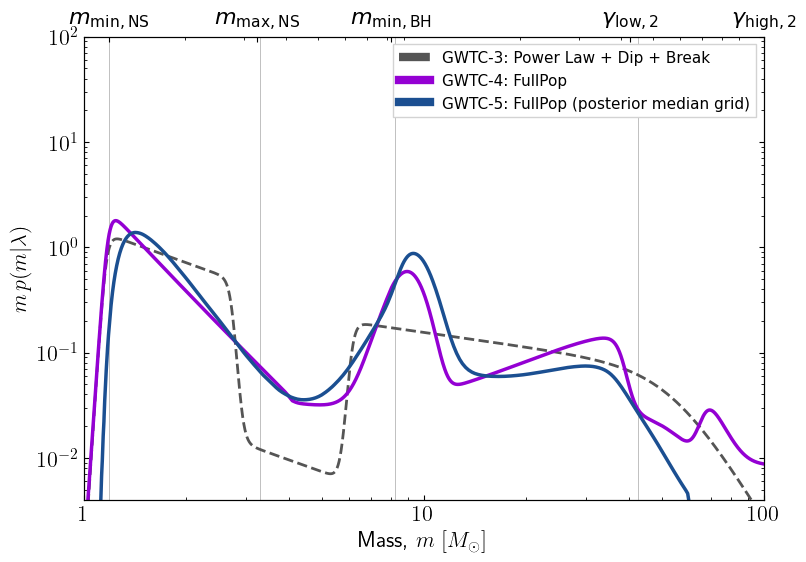

In [247]:
# ============================================================================
# Grid / sampling constants
# ============================================================================
#: Number of points for the 1D mass axis used in the single-model plot.
N_MASS_1D: int = 1_000_000

#: Number of points per axis for the 2D joint-distribution grid.
#: Increase for publication quality; decrease for faster development runs.
N_MASS_2D: int = 1_000

#: Log-spaced mass range [M_sun] used for all theoretical curves.
MASS_MIN: float = 1.0  # M_sun - hard lower boundary (injection bound)
MASS_MAX: float = 100.0  # M_sun - hard upper boundary

#: Number of histogram bins (log-spaced) for the 1D marginal plots.
N_HIST_BINS: int = 100

#: Percentile of the 2D weighted distribution used as the colour-scale
#: upper limit (guards against single-pixel spikes swamping the palette).
VMAX_PERCENTILE: float = 99.0

#: How to compute the GWTC-5 mass curve:
#: "grid" uses the posterior-median 1D primary-mass rate grid directly
#: from the GWTC-5 popsummary file. This is the preferred representation
#: for GWTC-5 because it does not require selecting a single MAP
#: hyperparameter sample.
#:
#: "map" is retained only as a legacy/diagnostic option and evaluates
#: the analytic FullPop model at a single MAP hyperparameter sample.
FULLPOP5_CURVE: str = "grid"  #  "map"

# ------------------------------------------------------------------
#  Figure 1 - 1D model comparison: GWTC-3 PDB vs GWTC-4 FullPop-4.0
#  vs GWTC-5 FullPop, same axes (Petrov-style overlay of generations).
# ------------------------------------------------------------------
logger.info("Computing 1D mass distributions (N = %d points) ...", N_MASS_1D)
m_1d = np.geomspace(MASS_MIN, MASS_MAX, N_MASS_1D)

#: Full path to the GWTC-5.0 FullPop popsummary file, needed by both the
#: boundary markers (median branch) and the curve itself (grid branch).
GWTC5_FULLPOP_POPSUMMARY = str(
    Path(DATA_DIR)
    / (
        "production_1_mass_NotchFilterBinnedPairingMassDistribution_"
        "redshift_powerlaw_mag_iid_spin_magnitude_gaussian_tilt_"
        "iid_spin_orientation_popsummary.h5"
    )
)

# Boundary markers: posterior median under "grid" (matches the curve),
# MAP sample under "map". The cached hyperparams_map.csv only carries
# MAP values, so the median branch loads the full posterior samples
# directly from the popsummary file via PopulationResult. Labels
# harmonised with the equations: only the upper (pair-instability) gap
# uses gamma_low,2 / gamma_high,2; the lower (NS-BH) gap bounds are
# m_max,NS and m_min,BH, not gamma_low,1 / gamma_high,1.
if FULLPOP5_CURVE == "grid":
    # Read from the cached hyperparams_median.csv (built once by
    # scripts/hyperparams/get_hyperparams.py) instead of reloading the
    # full posterior samples from the popsummary file every time.
    _hyper5_median = hyperparams_median.loc["GWTC-5.0 (popsummary)"]
    boundary_masses = [
        _hyper5_median["NSmin"],
        _hyper5_median["NSmax"],
        _hyper5_median["BHmin"],
        _hyper5_median["UPPERmin"],
        _hyper5_median["UPPERmax"],
    ]
else:
    boundary_masses = [
        hyperparams5["NSmin"],
        hyperparams5["NSmax"],
        hyperparams5["BHmin"],
        hyperparams5["UPPERmin"],
        hyperparams5["UPPERmax"],
    ]
boundary_labels = [
    r"$m_{\mathrm{min,NS}}$",
    r"$m_{\mathrm{max,NS}}$",
    r"$m_{\mathrm{min,BH}}$",
    r"$\gamma_{\mathrm{low,2}}$",
    r"$\gamma_{\mathrm{high,2}}$",
]

# -- GWTC-5 FullPop curve: grid/median or MAP, per FULLPOP5_CURVE -------------
if FULLPOP5_CURVE == "grid":
    # Same cached 2D joint grid the diagnostic cell below loads (built
    # once by scripts/hyperparams/get_hyperparams.py into data/derived/),
    # marginalised over m2, rather than opening the ~25 GB popsummary.h5
    # for the separate 1D-only primary_mass grid -- that dataset isn't
    # cached, but it represents the same posterior median as this one.
    # Axis convention (stored as rates[m2_index, m1_index], so axis0=m2)
    # verified with an assert in the diagnostic cell below.
    _grids5_1d = np.load(os.path.join(DERIVED_DIR, "GWTC-5_0__popsummary__grids.npz"))
    _grid_name_1d = "primary_mass_secondary_mass_joint_median"
    grid_mass = _grids5_1d[f"{_grid_name_1d}__m1"]
    _m2_pos_1d = _grids5_1d[f"{_grid_name_1d}__m2"]
    _rates_1d = _grids5_1d[f"{_grid_name_1d}__rates"]
    grid_median_rate = np.trapezoid(_rates_1d, _m2_pos_1d, axis=0)

    model_fullpop5 = np.interp(
        m_1d,
        grid_mass,
        grid_median_rate,
        left=0.0,
        right=0.0,
    )

    fullpop5_label = "GWTC-5: FullPop (posterior median grid)"

elif FULLPOP5_CURVE == "map":
    model_fullpop5 = fullpop(m_1d, hyperparams5)
    fullpop5_label = "GWTC-5: FullPop (MAP)"
else:
    raise ValueError(f"Unknown FULLPOP5_CURVE: {FULLPOP5_CURVE!r}")

# -- Normalise -----------------------------------------------------------------
model_fullpop4 = fullpop(m_1d, hyperparams4)
model_pdb = power_law_dip_break(m_1d)

fp4_normed = normalise_log(m_1d, model_fullpop4)
fp5_normed = normalise_log(m_1d, model_fullpop5)
pdb_normed = normalise_log(m_1d, model_pdb)

# -- Plot ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

plt.style.use("default")
plt.rcParams.update(
    {
        "font.size": 12,
        "axes.labelsize": 14,
        "legend.fontsize": 11,
    }
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.plot(
    m_1d,
    m_1d * pdb_normed,
    color="#555555",
    lw=2,
    ls="--",
    label="GWTC-3: Power Law + Dip + Break",
)
ax.plot(
    m_1d, m_1d * fp4_normed, color="#9400D3", lw=2.5, ls="-", label="GWTC-4: FullPop"
)
ax.plot(m_1d, m_1d * fp5_normed, color="#1B4F91", lw=2.5, ls="-", label=fullpop5_label)

ax.set_xlim(MASS_MIN, MASS_MAX)
ax.set_ylim(1e-3 * 4, 100)
ax.set_xlabel(r"Mass, $m\;[M_\odot]$", fontsize=16)
ax.set_ylabel(r"$m\,p(m|\lambda)$", fontsize=16)
ax.legend(
    loc="upper right",
    frameon=True,
    framealpha=1.0,
    edgecolor="lightgray",
    fancybox=False,
)
ax.tick_params(which="both", direction="in", top=False, right=True)

# -- Secondary x-axis ----------------------------------------------------------
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xscale("log")
ax2.set_xticks(boundary_masses)
ax2.set_xticklabels(boundary_labels, fontsize=16)
ax2.tick_params(which="both", direction="in")

for xv in boundary_masses:
    ax.axvline(x=xv, color="gray", lw=0.7, alpha=0.5, zorder=0)

fig.tight_layout(pad=0.4)
plt.subplots_adjust(top=0.87)
plt.show()

2026-09-03 16:32:52  INFO      GWTC-5.0 analytic vs. grid-median p(m1): median rel. diff = 24.85%, max rel. diff = 101.14%


GWTC-5.0 analytic vs. grid-median p(m1): median rel. diff = 24.85%, max rel. diff = 101.14%


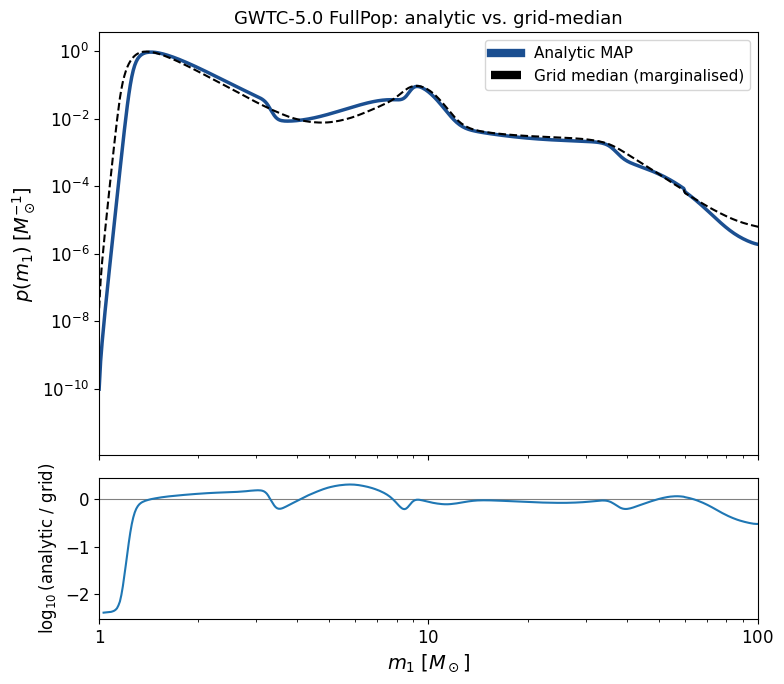

In [248]:
# Diagnostic: analytic MAP model vs. grid-median, GWTC-5.0.
# Compares fullpop(m, hyperparams5) to the posterior-median rate grid,
# marginalised over m2. Few % difference -> MAP is a fair stand-in;
# tens of % -> use the grid instead.
#
# Axis-order note: despite its name, primary_mass_secondary_mass_joint_median
# is stored as rates[m2_index, m1_index] (transposed) -- verified by checking
# that assuming axis0=m1 puts 95% of the rate mass in the unphysical m2>m1
# region, while axis0=m2 puts ~100% in the physical m2<=m1 region.
_grids5 = np.load(os.path.join(DERIVED_DIR, "GWTC-5_0__popsummary__grids.npz"))
_grid_name = "primary_mass_secondary_mass_joint_median"
m1_grid_pos = _grids5[f"{_grid_name}__m1"]
m2_grid_pos = _grids5[f"{_grid_name}__m2"]
median_rates = _grids5[f"{_grid_name}__rates"]

# Sanity check: nearly all rate mass should satisfy m2 <= m1.
M1_check, M2_check = np.meshgrid(m1_grid_pos, m2_grid_pos, indexing="ij")
physical_mass_fraction = median_rates.T[M2_check <= M1_check].sum() / median_rates.sum()
assert physical_mass_fraction > 0.99, (
    f"expected axis0=m2, axis1=m1 to put ~all rate mass in the physical "
    f"m2<=m1 region; got {physical_mass_fraction:.2%} -- grid layout may "
    f"have changed, re-check the orientation before trusting this cell"
)

# Marginalise over m2 (axis0) to obtain p(m1), then normalise
p_m1_grid = np.trapezoid(median_rates, m2_grid_pos, axis=0)
p_m1_grid_normed = normalise(m1_grid_pos, p_m1_grid)

# Build the 2D analytic joint distribution the same way as the GWTC-4.0
# cell above (pairing function + m1>60/m2<3 cut), then marginalise over m2
# -- a fair comparison to the grid, which already excludes that region.
model_1d_on_grid = fullpop(m1_grid_pos, hyperparams5)
pdf_1d_on_grid = model_1d_on_grid / np.trapezoid(model_1d_on_grid, m1_grid_pos)

M1_analytic, M2_analytic = np.meshgrid(m1_grid_pos, m1_grid_pos)
q_analytic = M2_analytic / M1_analytic
beta_pair_1_5 = hyperparams5["beta_pair_1"]
beta_pair_2_5 = hyperparams5["beta_pair_2"]
mbreak_5 = hyperparams5["mbreak"]

p_m1m2_analytic = np.outer(pdf_1d_on_grid, pdf_1d_on_grid) * (
    (M2_analytic < mbreak_5) * q_analytic**beta_pair_1_5
    + (M2_analytic >= mbreak_5) * q_analytic**beta_pair_2_5
)
p_m1m2_analytic *= (M1_analytic >= M2_analytic) & ~(
    (M1_analytic > 60) & (M2_analytic < 3)
)

p_m1_analytic_marginal = np.trapezoid(p_m1m2_analytic, m1_grid_pos, axis=0)
p_m1_analytic_normed = normalise(m1_grid_pos, p_m1_analytic_marginal)

# Mask near-zero values to avoid blowing up the ratio in the tails.
mask = p_m1_grid_normed > 1e-6 * p_m1_grid_normed.max()
rel_diff_pct = 100 * np.abs(p_m1_analytic_normed[mask] / p_m1_grid_normed[mask] - 1)

logger.info(
    "GWTC-5.0 analytic vs. grid-median p(m1): median rel. diff = %.2f%%, "
    "max rel. diff = %.2f%%",
    np.median(rel_diff_pct),
    np.max(rel_diff_pct),
)
print(
    f"GWTC-5.0 analytic vs. grid-median p(m1): "
    f"median rel. diff = {np.median(rel_diff_pct):.2f}%, "
    f"max rel. diff = {np.max(rel_diff_pct):.2f}%"
)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(8, 7), sharex=True, height_ratios=[3, 1]
)

ax_top.set_xscale("log")
ax_top.set_yscale("log")
ax_top.plot(
    m1_grid_pos,
    p_m1_analytic_normed,
    color="#1B4F91",
    lw=2.5,
    label="Analytic MAP",
)
ax_top.plot(
    m1_grid_pos,
    p_m1_grid_normed,
    color="black",
    lw=1.5,
    ls="--",
    label="Grid median (marginalised)",
)
ax_top.set_ylabel(r"$p(m_1)\;[M_\odot^{-1}]$", fontsize=14)
ax_top.legend(frameon=True)
ax_top.set_title("GWTC-5.0 FullPop: analytic vs. grid-median", fontsize=13)

log_ratio = np.log10(p_m1_analytic_normed[mask] / p_m1_grid_normed[mask])

ax_bot.set_xscale("log")
ax_bot.axhline(0, color="gray", lw=0.8)
ax_bot.plot(
    m1_grid_pos[mask],
    log_ratio,
    color="#1F77B4",
    lw=1.5,
)
ax_bot.set_ylabel(r"$\log_{10}$(analytic / grid)", fontsize=12)
ax_bot.set_xlabel(r"$m_1\;[M_\odot]$", fontsize=14)
ax_top.set_xlim(MASS_MIN, MASS_MAX)

fig.tight_layout()
plt.show()

**Scope note.** The 2D joint-distribution and posterior-predictive sections
below now use GWTC-5.0: MAP hyperparameters reinjected into the same
analytic formula, with the m1>60/m2<3 cut applied (see the diagnostic
above -- doing so brings the MAP/grid-median disagreement down to ~25%
median, concentrated in the NS-BH gap and the high-mass tail).

## Theoritical modeling for 2D Mass Distribution
### Plot posterior-predictive samples histograms (GWTC-5.0 distribution) vs. theoretical PDF

In [249]:
# ============================================================================
# Load posterior-predictive samples
# ============================================================================
# Picks the sample file matching FULLPOP5_CURVE (set in the Figure 1 cell
# above): fullpop_grid.h5 for "grid", fullpop_MAP.h5 (MAP) for "map".
# CBC_MASS_DISTRIBUTION_FILE_GWTC5 itself is left untouched -- it is also
# used earlier in this notebook (the first mass-distribution load), which
# is not part of this grid/MAP toggle.
_cbc_sample_file = os.path.join(
    DATA_DIR, "fullpop_grid.h5" if FULLPOP5_CURVE == "grid" else "fullpop_MAP.h5"
)

try:
    logger.info("Loading CBC samples from: %s", _cbc_sample_file)
    table = Table.read(_cbc_sample_file)
    m1_samples = np.asarray(table["mass1"])
    m2_samples = np.asarray(table["mass2"])
except Exception as e:
    logger.error(f"Failed to load CBC Mass Distributions: {e}")
    raise

logger.info(
    "Loaded %d CBC samples (%s)  |  m1 \u2208 [%.2f, %.2f]  |  m2 \u2208 [%.2f, %.2f]",
    len(m1_samples),
    FULLPOP5_CURVE,
    m1_samples.min(),
    m1_samples.max(),
    m2_samples.min(),
    m2_samples.max(),
)

2026-09-03 16:32:52  INFO      Loading CBC samples from: ../../data/raw/fullpop_grid.h5
2026-09-03 16:32:52  INFO      Loaded 1497920 CBC samples (grid)  |  m1 ∈ [1.07, 247.98]  |  m2 ∈ [1.00, 197.74]


2026-09-03 16:32:52  INFO      Building 2D mass grid (1000 × 1000) ...


[  1.           1.04761575   1.09749877   1.149757
   1.20450354   1.26185688   1.32194115   1.38488637
   1.45082878   1.51991108   1.59228279   1.66810054
   1.7475284    1.83073828   1.91791026   2.009233
   2.10490414   2.20513074   2.3101297    2.42012826
   2.53536449   2.65608778   2.7825594    2.91505306
   3.05385551   3.19926714   3.35160265   3.51119173
   3.67837977   3.85352859   4.03701726   4.22924287
   4.43062146   4.64158883   4.86260158   5.09413801
   5.33669923   5.59081018   5.85702082   6.13590727
   6.42807312   6.73415066   7.05480231   7.39072203
   7.74263683   8.11130831   8.49753436   8.90215085
   9.32603347   9.77009957  10.23531022  10.72267222
  11.23324033  11.76811952  12.32846739  12.91549665
  13.53047775  14.17474163  14.84968262  15.55676144
  16.29750835  17.07352647  17.88649529  18.73817423
  19.6304065   20.56512308  21.5443469   22.5701972
  23.64489413  24.77076356  25.95024211  27.18588243
  28.48035868  29.8364724   31.2571585   32.7454916

2026-09-03 16:32:53  INFO      Integral of p($m_1$) dm = 0.9999999999999998 (expected 1.0)
2026-09-03 16:32:53  INFO      Integral of p($m_2$) dm = 1.0 (expected 1.0)


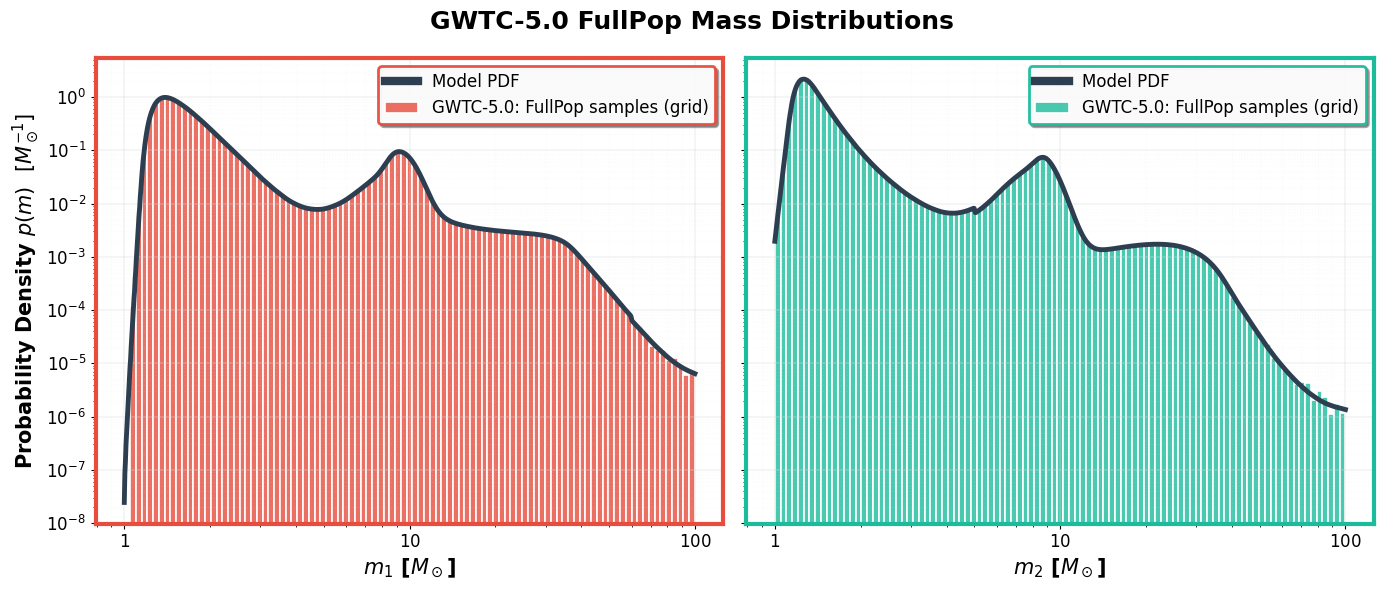

In [250]:
# ============================================================================
# Plot colour palette
# ============================================================================
COLORS: dict = {
    "m1": "#E74C3C",  # coral  - primary mass
    "m2": "#1ABC9C",  # teal   - secondary mass
    "model": "#2C3E50",  # slate  - theoretical curves
}


# ------------------------------------------------------------------
#  Compute 2D joint distribution and marginals
# ------------------------------------------------------------------
logger.info("Building 2D mass grid (%d × %d) ...", N_MASS_2D, N_MASS_2D)
m_2d = np.geomspace(MASS_MIN, MASS_MAX, N_MASS_2D)
m1_grid, m2_grid = np.meshgrid(m_2d, m_2d)
_exclude = (m1_grid >= m2_grid) & ~((m1_grid > 60) & (m2_grid < 3))

if FULLPOP5_CURVE == "grid":
    # Read the joint m1-m2 rate grid directly and take the posterior
    # median -- pairing is already baked into this grid (no beta_pair_1/2,
    # mbreak needed), unlike the MAP branch below which reconstructs it
    # by hand. Reshape order (L, L, -1) then axis=2 verified earlier
    # against the file's own primary_mass_secondary_mass_joint_median
    # dataset (see the FIXME discussion for population.py L31).
    #
    # IMPORTANT axis convention, verified empirically (not documented
    # anywhere in the file): axis 0 of the reshaped array is m2 (the
    # smaller mass), axis 1 is m1 (the larger mass) -- backwards from
    # the naive "axis0=primary_mass" guess. Checked by masking each way
    # and counting nonzero cells: with axis0=m2/axis1=m1, all 141,875
    # nonzero cells satisfy axis0 <= axis1 (physically m2 <= m1); the
    # opposite assignment leaves only 565 nonzero cells in the "valid"
    # region, which is population.py's own reason for never assuming an
    # ordering on this grid and instead swapping m1/m2 by hand *after*
    # sampling from it.
    # Reads the already-cached posterior-median grid (built once by
    # scripts/hyperparams/get_hyperparams.py into data/derived/) instead
    # of opening the ~25 GB popsummary.h5 for
    # primary_mass_secondary_mass_joint_full_posterior and reducing it by
    # hand: primary_mass_secondary_mass_joint_median *is* that same
    # np.median reduction, precomputed. Same axis convention as the
    # diagnostic cell below: stored as rates[m2_index, m1_index], so
    # axis0 is m2, matching axis0_m2/axis1_m1 below without a transpose.
    _grids5_2d = np.load(os.path.join(DERIVED_DIR, "GWTC-5_0__popsummary__grids.npz"))
    _grid_name_2d = "primary_mass_secondary_mass_joint_median"
    _grid_mass = _grids5_2d[f"{_grid_name_2d}__m1"]
    _grid_rates_2d = _grids5_2d[f"{_grid_name_2d}__rates"]

    _axis0_m2, _axis1_m1 = np.meshgrid(_grid_mass, _grid_mass, indexing="ij")
    _grid_rates_2d = _grid_rates_2d * (
        (_axis1_m1 >= _axis0_m2) & ~((_axis1_m1 > 60) & (_axis0_m2 < 3))
    )

    # Marginalize on the grid's own axis, then interpolate onto m_2d.
    # _grid_mass is log-spaced (fine steps at low mass, coarse at high
    # mass), so a plain .sum() over the axis implicitly under-weights the
    # high-mass tail (few points, each covering a large dm) relative to
    # the low-mass end (many points, small dm); np.trapezoid weights by
    # the actual local spacing, matching the true integral p(m) dm.
    # Integrate over axis0 (m2) to get the m1 marginal, and vice versa.
    from scipy.integrate import trapezoid

    _p_m1_native = trapezoid(_grid_rates_2d, _grid_mass, axis=0)  # integrate over m2
    _p_m2_native = trapezoid(_grid_rates_2d, _grid_mass, axis=1)  # integrate over m1
    p_m1_marginal = np.interp(m_2d, _grid_mass, _p_m1_native)
    p_m2_marginal = np.interp(m_2d, _grid_mass, _p_m2_native)

    # p_m1m2 on the (m_2d, m_2d) mesh, for the 2D heatmap figure below
    # (weighted_dist = m1_grid * m2_grid * p_m1m2). 2D-interpolated from
    # the native 600x600 grid; query points passed as (m2, m1) to match
    # the (axis0, axis1) = (m2, m1) convention above. Exclusion mask
    # re-applied since interpolation can leak small values across the
    # m1=m2 diagonal / the m1>60,m2<3 corner.
    from scipy.interpolate import RegularGridInterpolator

    _interp_joint = RegularGridInterpolator(
        (_grid_mass, _grid_mass), _grid_rates_2d, bounds_error=False, fill_value=0.0
    )
    p_m1m2 = _interp_joint(np.stack([m2_grid, m1_grid], axis=-1))
    p_m1m2 *= _exclude
    model2d_label = "GWTC-5.0: FullPop samples (grid)"

elif FULLPOP5_CURVE == "map":
    logger.warning(
        "Using the legacy analytic FullPop(MAP) representation for GWTC-5. "
        "The preferred GWTC-5 representation is the posterior-median grid."
    )
    model_fullpop5 = fullpop(m_1d, hyperparams5)
    fullpop5_label = "GWTC-5: FullPop (MAP; diagnostic)"

    # =================================
    model_2d = fullpop(m_2d, hyperparams5)
    pdf_1d = model_2d / simpson(model_2d, m_2d)  # integral of p dm = 1

    beta_pair_1 = hyperparams5["beta_pair_1"]
    beta_pair_2 = hyperparams5["beta_pair_2"]
    mbreak = hyperparams5["mbreak"]

    # Joint PDF with mass-ratio-dependent pairing
    q = m2_grid / m1_grid  # mass ratio, q ∈ (0, 1] since m2 <= m1
    p_m1m2 = np.outer(pdf_1d, pdf_1d) * (
        (m2_grid < mbreak) * q**beta_pair_1 + (m2_grid >= mbreak) * q**beta_pair_2
    )
    # Enforce m1 >= m2 and exclude the extreme mass-ratio region GWTC-5.0's
    # own inference excludes (m1>60, m2<3 -- see the diagnostic cell above).
    p_m1m2 *= _exclude

    # Marginalize to get 1D distribution
    p_m1_marginal = np.trapezoid(p_m1m2, m_2d, axis=0)  # Integrate over m2
    p_m2_marginal = np.trapezoid(p_m1m2, m_2d, axis=1)  # Integrate over m1
    model2d_label = "GWTC-5.0: FullPop samples (MAP)"
else:
    raise ValueError(f"Unknown FULLPOP5_CURVE: {FULLPOP5_CURVE!r}")


plt.style.use("default")
plt.rcParams.update(
    {
        "font.size": 12,
        "axes.labelsize": 14,
        "legend.fontsize": 11,
    }
)

# Shared log-spaced histogram bins
lo = max(MASS_MIN, min(m1_samples.min(), m2_samples.min(), m_2d.min()))
hi = min(MASS_MAX, max(m1_samples.max(), m2_samples.max(), m_2d.max()))
bins = np.geomspace(lo, hi, N_HIST_BINS)

print(70 * "=")
print(bins)
print(70 * "=")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

panels = [
    (axes[0], m1_samples, p_m1_marginal.copy(), r"$m_1$", "m1"),
    (axes[1], m2_samples, p_m2_marginal.copy(), r"$m_2$", "m2"),
]

# Collect right twin axes so we can share their y-scale across panels
ax_rights = []

for ax, samples, marginal, label, color_key in panels:
    color = COLORS[color_key]

    # --- Normalise: integral p(m) dm = 1  [M_sun^-1] ---
    marginal_normed = normalise(m_2d, marginal)

    # Sanity check - must equal 1.0
    integral = np.trapezoid(marginal_normed, m_2d)
    logger.info(f"Integral of p({label}) dm = {integral} (expected 1.0)")

    # --- Left axis: probability DENSITY p(m)  [M_sun^-1] ---
    sns.histplot(
        samples,
        bins=bins,
        stat="density",
        color=color,
        alpha=0.8,
        edgecolor="white",
        linewidth=1.2,
        ax=ax,
        label=model2d_label,
    )
    ax.plot(
        m_2d,
        marginal_normed,
        color=COLORS["model"],
        lw=3.5,
        label="Model PDF",
        zorder=10,
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(rf"{label} [$M_\odot$]", fontsize=15, fontweight="600")
    ax.grid(
        True, which="major", alpha=0.3, linestyle="-", linewidth=1.2, color="#D5DBDB"
    )
    ax.grid(
        True, which="minor", alpha=0.15, linestyle=":", linewidth=0.8, color="#E5E7E9"
    )

    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)

    legend = ax.legend(
        frameon=True,
        fancybox=True,
        shadow=True,
        fontsize=12,
        loc="upper right",
        edgecolor=color,
        facecolor="white",
        framealpha=0.95,
    )
    legend.get_frame().set_linewidth(2)


axes[0].set_ylabel(
    r"Probability Density $p(m)$  $[M_\odot^{-1}]$", fontsize=15, fontweight="600"
)

fig.suptitle(
    "GWTC-5.0 FullPop Mass Distributions", fontsize=18, fontweight="bold", y=0.98
)
plt.tight_layout()
plt.show()

### ------------------------------------------------------------------
### Visualise the 2D FullPop-4.0 joint mass distribution.
### ------------------------------------------------------------------

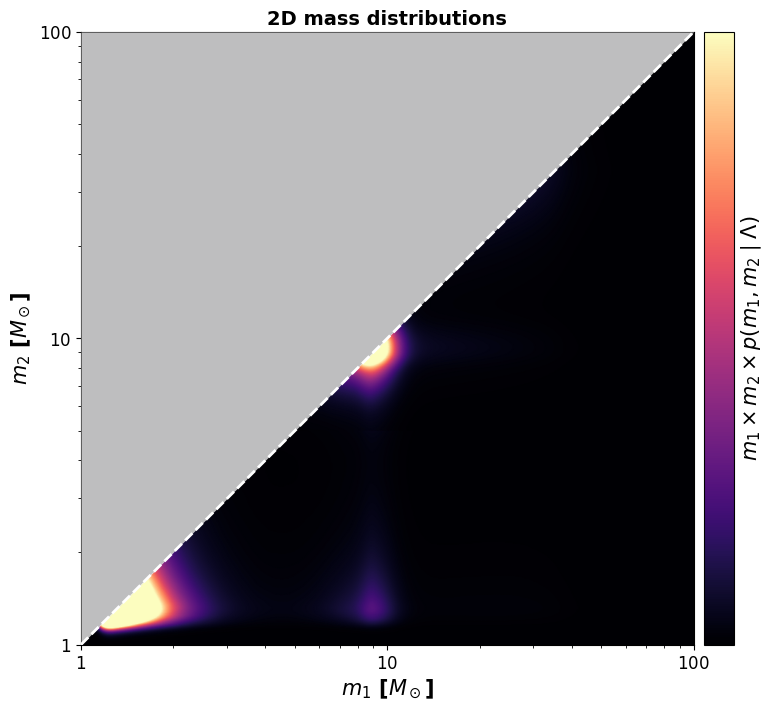

In [251]:
# Figure - 2D joint distribution
weighted_dist = m1_grid * m2_grid * p_m1m2

fig, ax = plt.subplots(figsize=(8, 7), subplot_kw=dict(aspect=1))
ax.set_xlim(MASS_MIN, MASS_MAX)
ax.set_ylim(MASS_MIN, MASS_MAX)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$m_1$ [$M_\odot$]", fontsize=15, fontweight="600")
ax.set_ylabel(r"$m_2$ [$M_\odot$]", fontsize=15, fontweight="600")

vmax = np.percentile(weighted_dist[weighted_dist > 0], VMAX_PERCENTILE)

img = ax.pcolormesh(
    m_2d,
    m_2d,
    weighted_dist,
    vmin=0,
    vmax=vmax,
    shading="gouraud",
    rasterized=True,
    cmap="magma",
)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = plt.colorbar(img, cax=cax)
cbar.set_label(
    r"$m_1 \times m_2 \times p(m_1, m_2 \mid \Lambda)$",
    fontsize=15,
    fontweight="600",
)
cbar.set_ticks([])

# Mask unphysical region (m2 > m1)
ax.fill_between(
    [MASS_MIN, MASS_MAX],
    [MASS_MIN, MASS_MAX],
    [MASS_MAX, MASS_MAX],
    color="white",
    linewidth=0,
    alpha=0.75,
    zorder=10,
)

# Equal-mass line
ax.plot([MASS_MIN, MASS_MAX], [MASS_MIN, MASS_MAX], "--w", linewidth=2, zorder=11)

fig.suptitle(r"2D mass distributions", fontsize=14, fontweight="bold", y=0.99)
plt.tight_layout(pad=0.1)

### -------------------------------------------------------------------------
### The FullPop-4.0 CBC Distribution with Gaussian Kernel Density Estimation
### -------------------------------------------------------------------------

2026-09-03 16:34:03  INFO      Number of BNS: 59949, Number of NSBH: 13936, Number of BBH: 26115


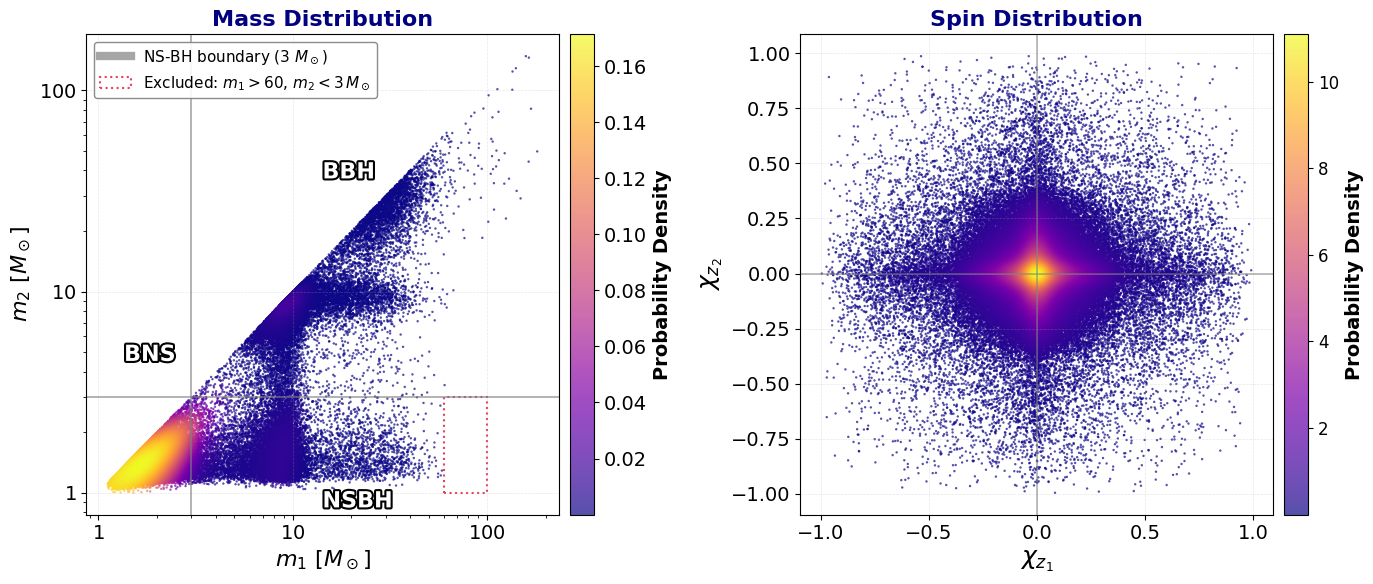

In [252]:
# ============================================================================
# Configuration
# ============================================================================
N_SAMPLES = 100_000
FIGURE_SIZE = (14, 6)
FONT_SIZE_LABEL = 16
FONT_SIZE_TICK = 14
FONT_SIZE_CBAR = 14
SCATTER_SIZE = 3
ALPHA = 0.7
COLORMAP = "plasma"  #'magma'

# ============================================================================
# Load and process data
# ============================================================================
fullpop4 = table
ns_max_mass = 3.0

# Clamped: table can hold fewer rows than N_SAMPLES depending on which
# cells were (re-)run before this one in the current kernel session.
_n_samples = min(N_SAMPLES, len(fullpop4))
idx = np.random.choice(len(fullpop4), size=_n_samples, replace=False)
fullpop4 = fullpop4[np.sort(idx)]

# ============================================================================
# Create combined visualization
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE)

# ============================================================================
# LEFT PLOT: Mass Distribution
# ============================================================================
ax1 = axes[0]

# Mass distribution (log scale)
mass1 = fullpop4["mass1"]
mass2 = fullpop4["mass2"]

# Compute KDE
xy_mass = np.vstack([mass1, mass2])
kde_mass = gaussian_kde(xy_mass, bw_method="scott")
z_mass = kde_mass(xy_mass)

# Sort by density
idx_mass = z_mass.argsort()
mass1_sorted = mass1[idx_mass]
mass2_sorted = mass2[idx_mass]
z_mass_sorted = z_mass[idx_mass]

# Create scatter plot
scatter1 = ax1.scatter(
    mass1_sorted,
    mass2_sorted,
    c=z_mass_sorted,
    s=SCATTER_SIZE,
    cmap=COLORMAP,
    alpha=ALPHA,
    edgecolors="none",
    rasterized=True,
)

# Add separation lines for BNS/NSBH/BBH
# Horizontal line at ns_max_mass (separates NS from BH on mass2 axis)
ax1.axhline(
    y=ns_max_mass,
    color="gray",
    linestyle="-",
    linewidth=1.2,
    label=f"NS-BH boundary ({ns_max_mass:.0f} $M_\\odot$)",
    alpha=0.7,
)

# Vertical line at ns_max_mass (separates NS from BH on mass1 axis)
ax1.axvline(x=ns_max_mass, color="gray", linestyle="-", linewidth=1.2, alpha=0.7)

# Excluded region (m1>60, m2<3): GWTC-5.0's own inference has no simulated
# injections there, so the region is cut from the population (see the
# diagnostic and 2D analytic cells above) -- draw its boundary explicitly,
# since it would otherwise look like ordinary sparsity at extreme mass ratio.
ax1.add_patch(
    Rectangle(
        (60, 1),
        100 - 60,
        3 - 1,
        linewidth=1.5,
        edgecolor="crimson",
        facecolor="none",
        linestyle=":",
        alpha=0.8,
        label=r"Excluded: $m_1>60$, $m_2<3\,M_\odot$",
    )
)

# Add text labels for regions with white text and black outline for better visibility
text_style = [withStroke(linewidth=3, foreground="black")]

ax1.text(
    0.08,
    0.32,
    "BNS",
    transform=ax1.transAxes,
    fontsize=16,
    fontweight="bold",
    color="white",
    path_effects=text_style,
)

ax1.text(
    0.5,
    0.015,
    "NSBH",
    transform=ax1.transAxes,
    fontsize=16,
    fontweight="bold",
    color="white",
    path_effects=text_style,
)

ax1.text(
    0.5,
    0.7,
    "BBH",
    transform=ax1.transAxes,
    fontsize=16,
    fontweight="bold",
    color="white",
    path_effects=text_style,
)

# Customize axes
ax1.set_xlabel(r"$ m_1 \ [M_\odot]$", fontsize=FONT_SIZE_LABEL, fontweight="bold")
ax1.set_ylabel(r"$ m_2 \ [M_\odot]$", fontsize=FONT_SIZE_LABEL, fontweight="bold")
ax1.tick_params(axis="both", which="major", labelsize=FONT_SIZE_TICK)
ax1.set_title(
    r"Mass Distribution", color="navy", fontsize=FONT_SIZE_LABEL, fontweight="bold"
)

# Add grid for axis 1
ax1.grid(True, alpha=0.3, linestyle="--", linewidth=0.5)

# Add legend with better formatting
ax1.legend(loc="upper left", fontsize=11, framealpha=0.9, edgecolor="gray")

# Colorbar for mass 1
cbar1 = fig.colorbar(scatter1, ax=ax1, pad=0.02)
cbar1.set_label("Probability Density", fontsize=FONT_SIZE_CBAR, fontweight="bold")
cbar1.ax.tick_params(labelsize=FONT_SIZE_TICK)

ax1.set_xscale("log")
ax1.set_yscale("log")
# ============================================================================
# RIGHT PLOT: Spin Distribution
# ============================================================================
ax2 = axes[1]

# Extract spin data
spin1z = fullpop4["spin1z"]
spin2z = fullpop4["spin2z"]

# Compute KDE for masses
xy_spin = np.vstack([spin1z, spin2z])
kde_spin = gaussian_kde(xy_spin, bw_method="scott")
z_spin = kde_spin(xy_spin)

# Sort by density for spins
idx_spin = z_spin.argsort()
spin1z_sorted = spin1z[idx_spin]
spin2z_sorted = spin2z[idx_spin]
z_spin_sorted = z_spin[idx_spin]

# Scatter plot
scatter2 = ax2.scatter(
    spin1z_sorted,
    spin2z_sorted,
    c=z_spin_sorted,
    s=SCATTER_SIZE,
    cmap=COLORMAP,
    alpha=ALPHA,
    edgecolors="none",
    rasterized=True,
)

ax2.set_xlabel(r"$\chi_{z_1}$", fontsize=FONT_SIZE_LABEL + 2, fontweight="bold")
ax2.set_ylabel(r"$\chi_{z_2}$", fontsize=FONT_SIZE_LABEL + 2, fontweight="bold")
ax2.tick_params(axis="both", which="major", labelsize=FONT_SIZE_TICK)
ax2.set_title(
    r"Spin Distribution", color="navy", fontsize=FONT_SIZE_LABEL, fontweight="bold"
)

# Add grid for axis 2
ax2.grid(True, alpha=0.3, linestyle="--", linewidth=0.5)

# Add reference lines at zero (slightly darker for print visibility)
ax2.axhline(y=0, color="gray", linestyle="-", linewidth=1.2, alpha=0.6)
ax2.axvline(x=0, color="gray", linestyle="-", linewidth=1.2, alpha=0.6)

# Colorbar
cbar2 = fig.colorbar(scatter2, ax=ax2, pad=0.02)
cbar2.set_label("Probability Density", fontsize=FONT_SIZE_CBAR, fontweight="bold")
cbar1.ax.tick_params(labelsize=FONT_SIZE_TICK)
plt.tight_layout()

# ============================================================================
# Print population statistics
# ============================================================================
logger.info(
    f"Number of BNS: {len(fullpop4[(fullpop4['mass1'] < ns_max_mass)])}, "
    f"Number of NSBH: {len(fullpop4[(fullpop4['mass1'] >= ns_max_mass) & (fullpop4['mass2'] < ns_max_mass)])}, "
    f"Number of BBH: {len(fullpop4[(fullpop4['mass2'] >= ns_max_mass)])}"
)
plt.show()
plt.close()

In [253]:
# ============================================================================
# Telescope configurations
# ============================================================================

TELESCOPES = {
    "GOTO": {"mlim": 20.0, "Mabs": -16},
    "ZTF": {"mlim": 22.0, "Mabs": -16},
    "Vera C. Rubin": {"mlim": 25.7, "Mabs": -16},
}


# -- Shared config, FullPop over IR1 --------------------------------------------
# datapath/run_names/model match kn_detection.py's own RUNS_DIR default:
# data/runs/{IR1HL,IR1HLV}/fullpop/. run_durations is the real calendar
# duration of each run, in years -- kn_detection.py now computes the
# expected GW detection count (lambda = R_i * V_s * T_obs) live from the
# run's own simulated catalogue instead of taking a fixed, rounded-median
# count as an argument, so all that's needed here is T_obs. IR1 is a
# planned six-month campaign, hence 0.5 for both networks.
COMMON = dict(
    datapath="../../data/runs",
    run_names=["IR1HL", "IR1HLV"],
    model="fullpop",
    run_durations={"IR1HL": 0.5, "IR1HLV": 0.5},
    ns_max_mass=3.0,
    n_realizations=100_000,
    seed=42,
    verbose=True,
)

### -------------------------------------------------------------
###  Kilonova (KN) Detectability — Counterpart Detection Analysis
### -------------------------------------------------------------

GOTO KN detection horizon : 158.5 Mpc
  (m_lim=20.0, M_abs=-16)

  Run : IR1HL
  BNS
    Mean   : 0.0
    Median : 0  (+0 / -0)  [90% CI]
  NSBH
    Mean   : 0.0
    Median : 0  (+0 / -0)  [90% CI]

  Run : IR1HLV
  BNS
    Mean   : 0.1
    Median : 0  (+1 / -0)  [90% CI]
  NSBH
    Mean   : 0.0
    Median : 0  (+0 / -0)  [90% CI]



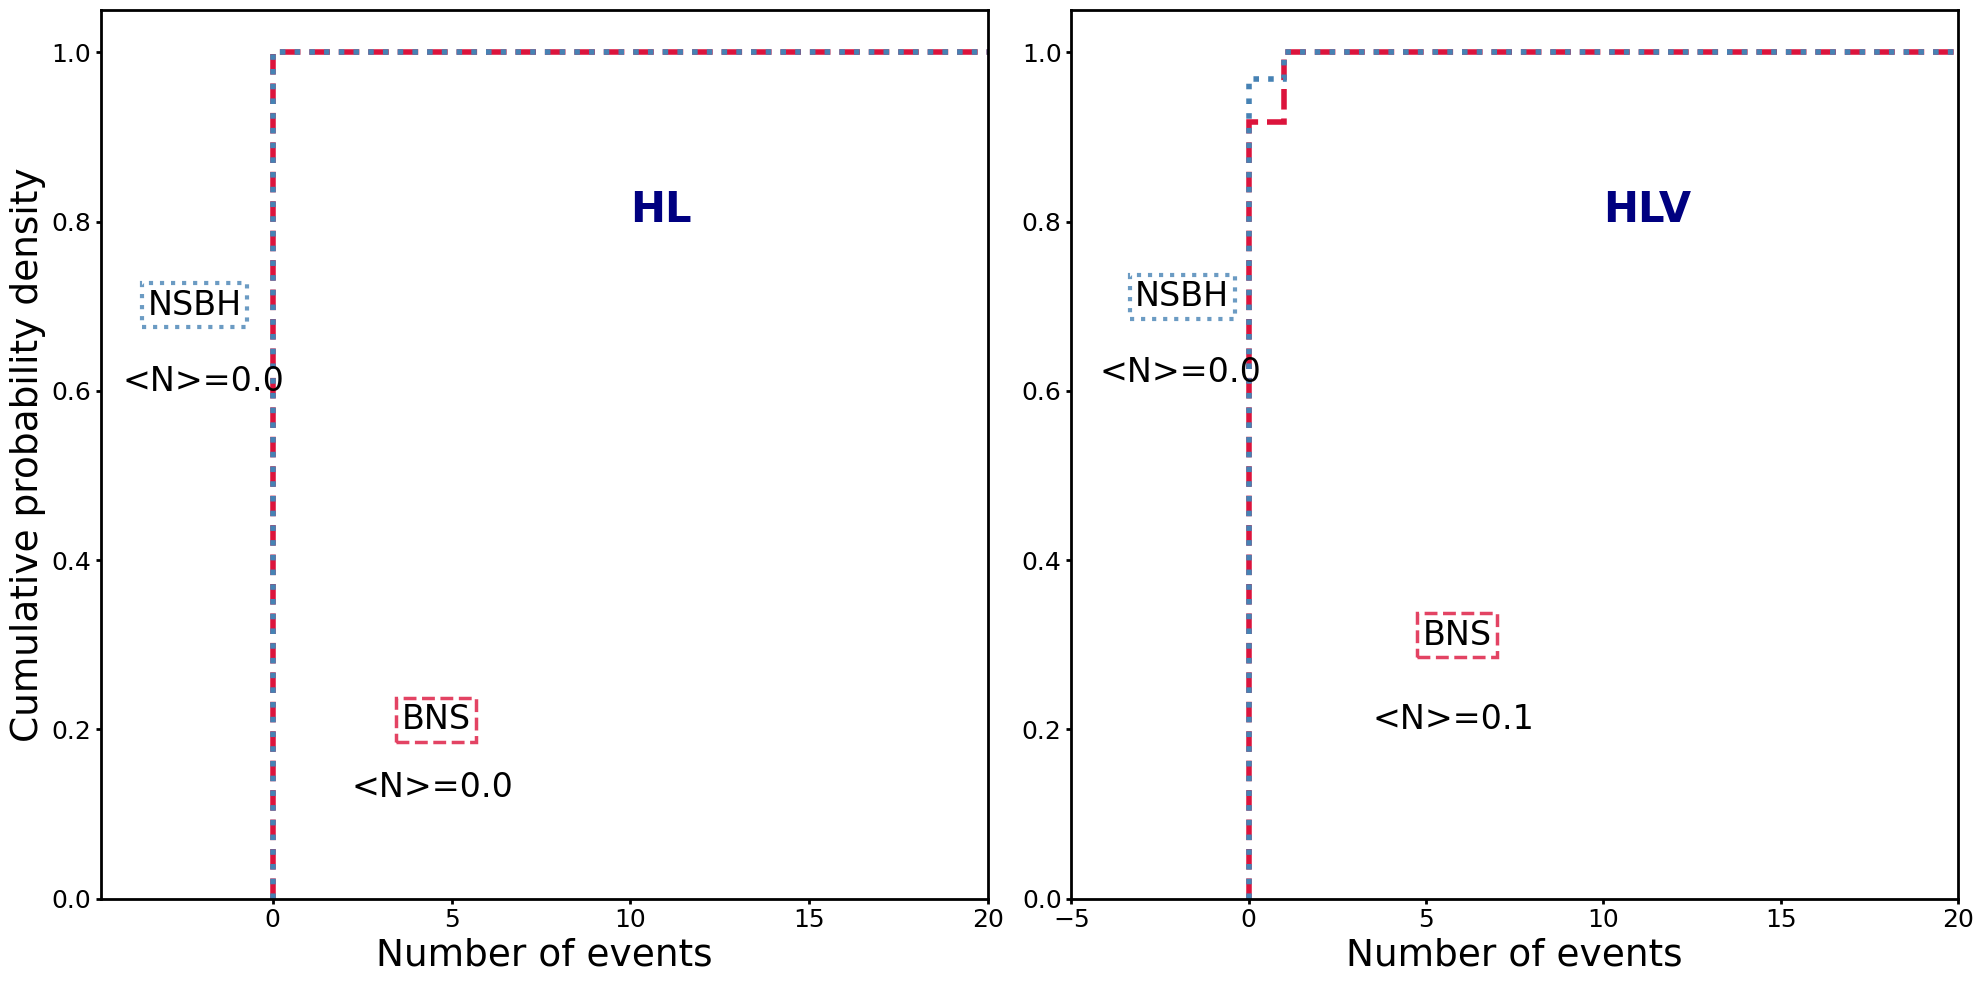

ZTF KN detection horizon : 398.1 Mpc
  (m_lim=22.0, M_abs=-16)

  Run : IR1HL
  BNS
    Mean   : 0.0
    Median : 0  (+0 / -0)  [90% CI]
  NSBH
    Mean   : 0.0
    Median : 0  (+0 / -0)  [90% CI]

  Run : IR1HLV
  BNS
    Mean   : 0.7
    Median : 1  (+0 / -1)  [90% CI]
  NSBH
    Mean   : 0.2
    Median : 0  (+1 / -0)  [90% CI]



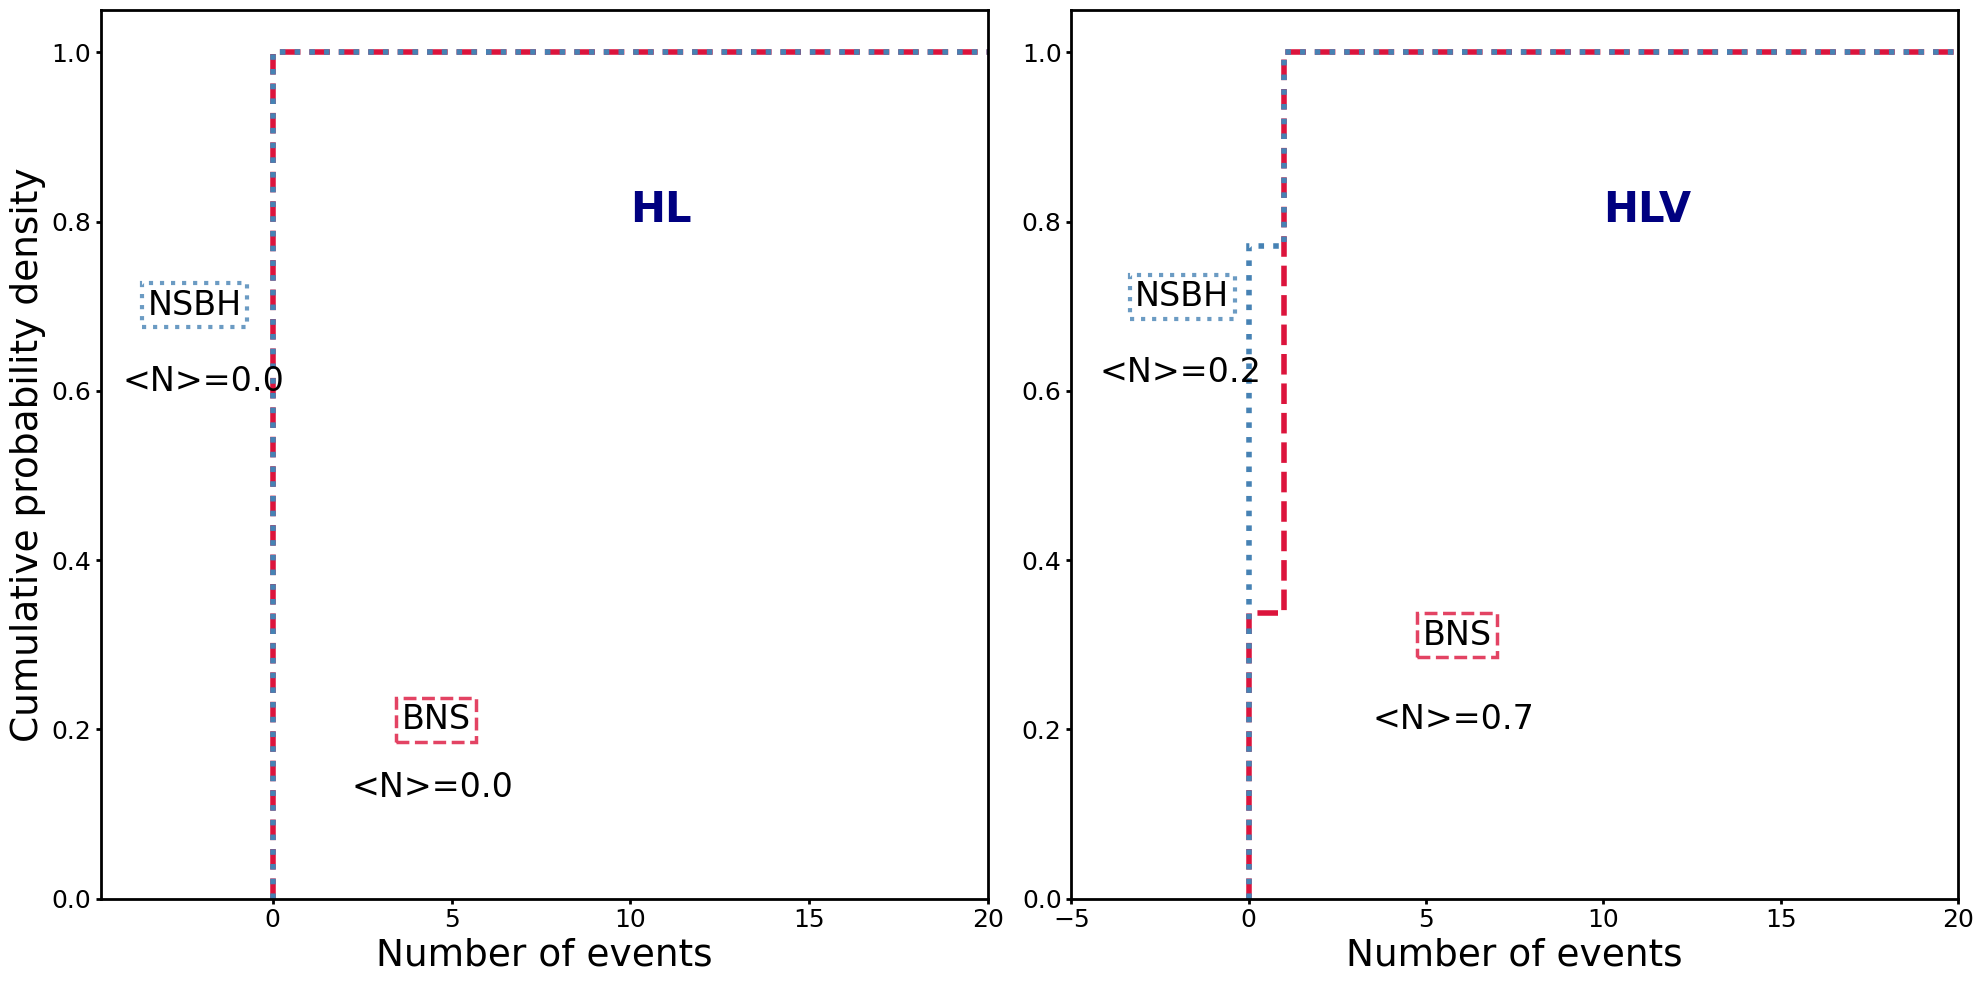

Vera C. Rubin KN detection horizon : 2187.8 Mpc
  (m_lim=25.7, M_abs=-16)

  Run : IR1HL
  BNS
    Mean   : 0.0
    Median : 0  (+0 / -0)  [90% CI]
  NSBH
    Mean   : 0.0
    Median : 0  (+0 / -0)  [90% CI]

  Run : IR1HLV
  BNS
    Mean   : 1.0
    Median : 1  (+0 / -0)  [90% CI]
  NSBH
    Mean   : 1.0
    Median : 1  (+0 / -0)  [90% CI]



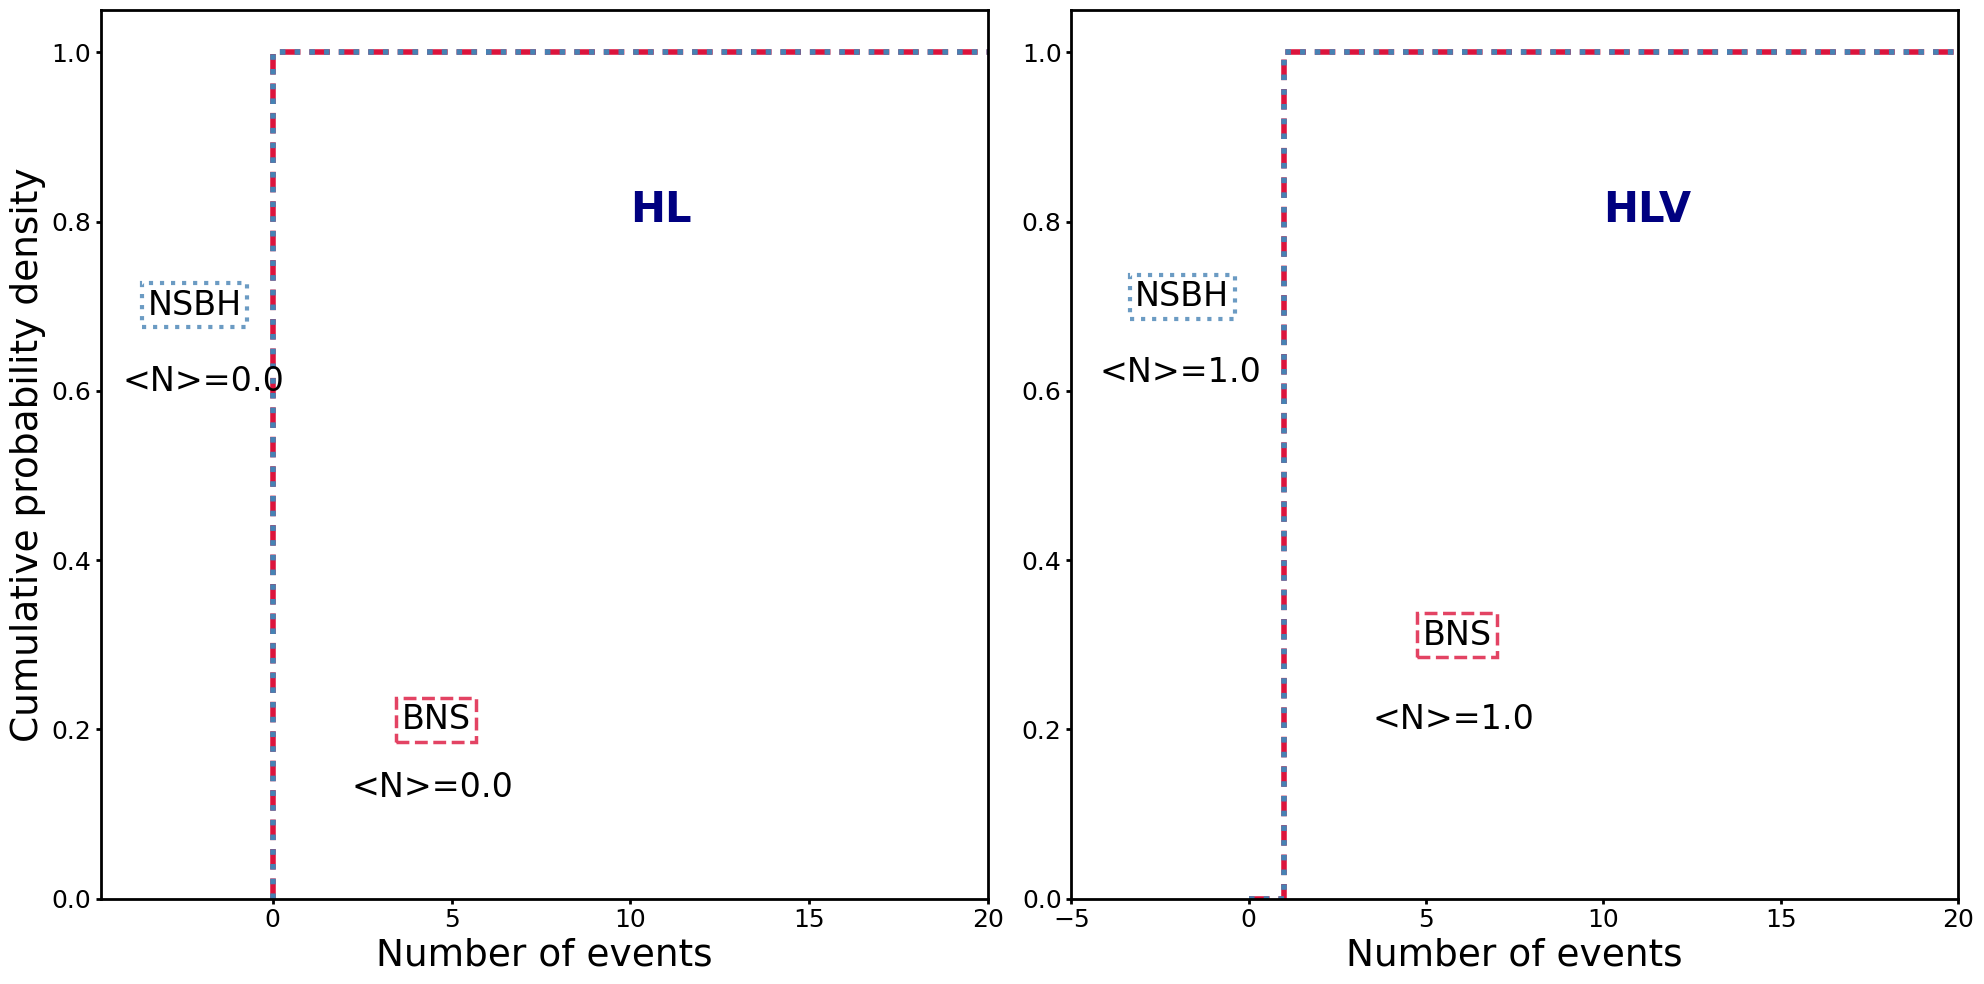

In [254]:
# Run the analysis for all three telescopes (not just ZTF -- GOTO and Vera
# C. Rubin are configured above too, and there is no reason left to skip
# them now that the data paths and expected counts are current).
for telescope, cfg in TELESCOPES.items():
    results, d_max = run_analysis(
        **COMMON,
        **cfg,
        telescope_name=telescope,
    )
    plot_results(
        results,
        run_names=COMMON["run_names"],
        telescope_name=telescope,
        outdir=None,
        show=True,
    )

### -------------------------------------------------------------
###  Kilonova (KN) Detectability for O5 (O5a/O5b/O5c) -- same
###  analysis as IR1 above, different run and run_durations
### -------------------------------------------------------------

GOTO KN detection horizon : 158.5 Mpc
  (m_lim=20.0, M_abs=-16)

  Run : O5a
  BNS
    Mean   : 0.4
    Median : 0  (+1 / -0)  [90% CI]
  NSBH
    Mean   : 0.1
    Median : 0  (+1 / -0)  [90% CI]

  Run : O5b
  BNS
    Mean   : 0.4
    Median : 0  (+2 / -0)  [90% CI]
  NSBH
    Mean   : 0.1
    Median : 0  (+1 / -0)  [90% CI]

  Run : O5c
  BNS
    Mean   : 0.5
    Median : 0  (+2 / -0)  [90% CI]
  NSBH
    Mean   : 0.1
    Median : 0  (+1 / -0)  [90% CI]



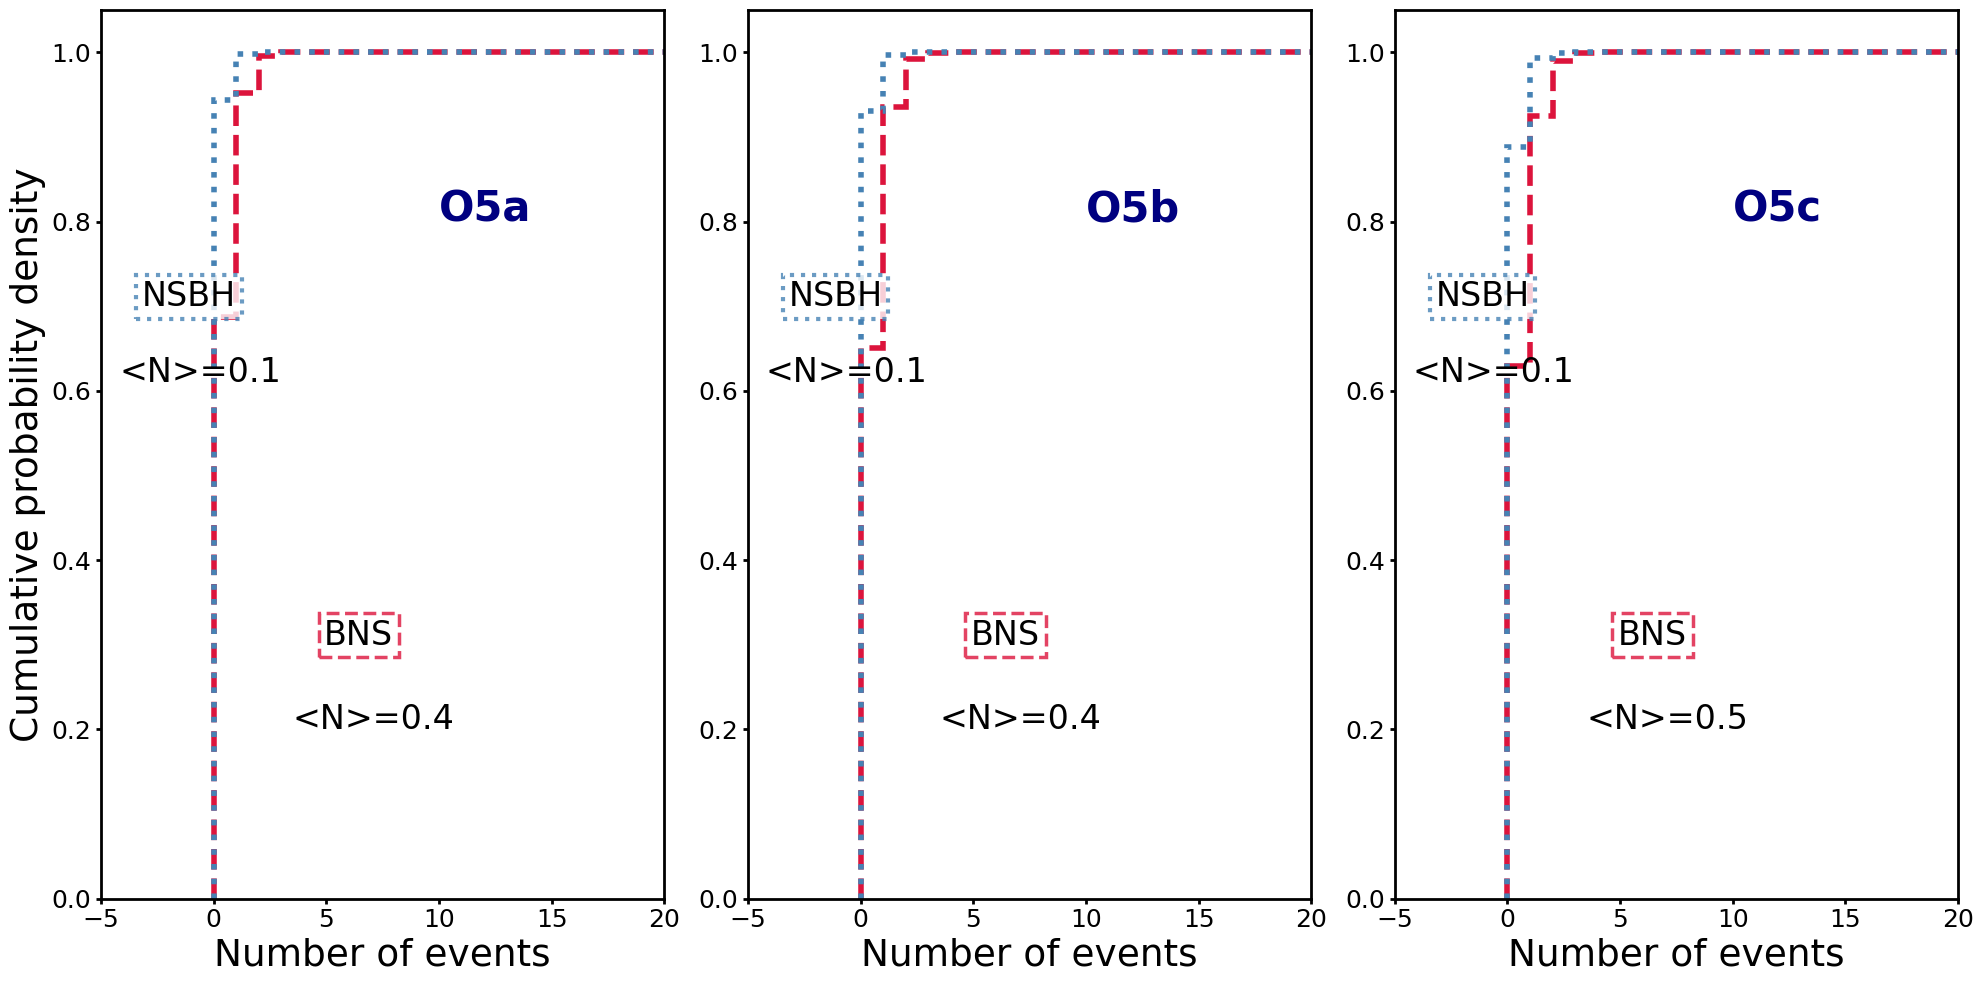

ZTF KN detection horizon : 398.1 Mpc
  (m_lim=22.0, M_abs=-16)

  Run : O5a
  BNS
    Mean   : 3.4
    Median : 3  (+3 / -2)  [90% CI]
  NSBH
    Mean   : 1.0
    Median : 1  (+2 / -1)  [90% CI]

  Run : O5b
  BNS
    Mean   : 3.5
    Median : 3  (+3 / -2)  [90% CI]
  NSBH
    Mean   : 1.1
    Median : 1  (+2 / -1)  [90% CI]

  Run : O5c
  BNS
    Mean   : 3.9
    Median : 4  (+3 / -3)  [90% CI]
  NSBH
    Mean   : 1.4
    Median : 1  (+2 / -1)  [90% CI]



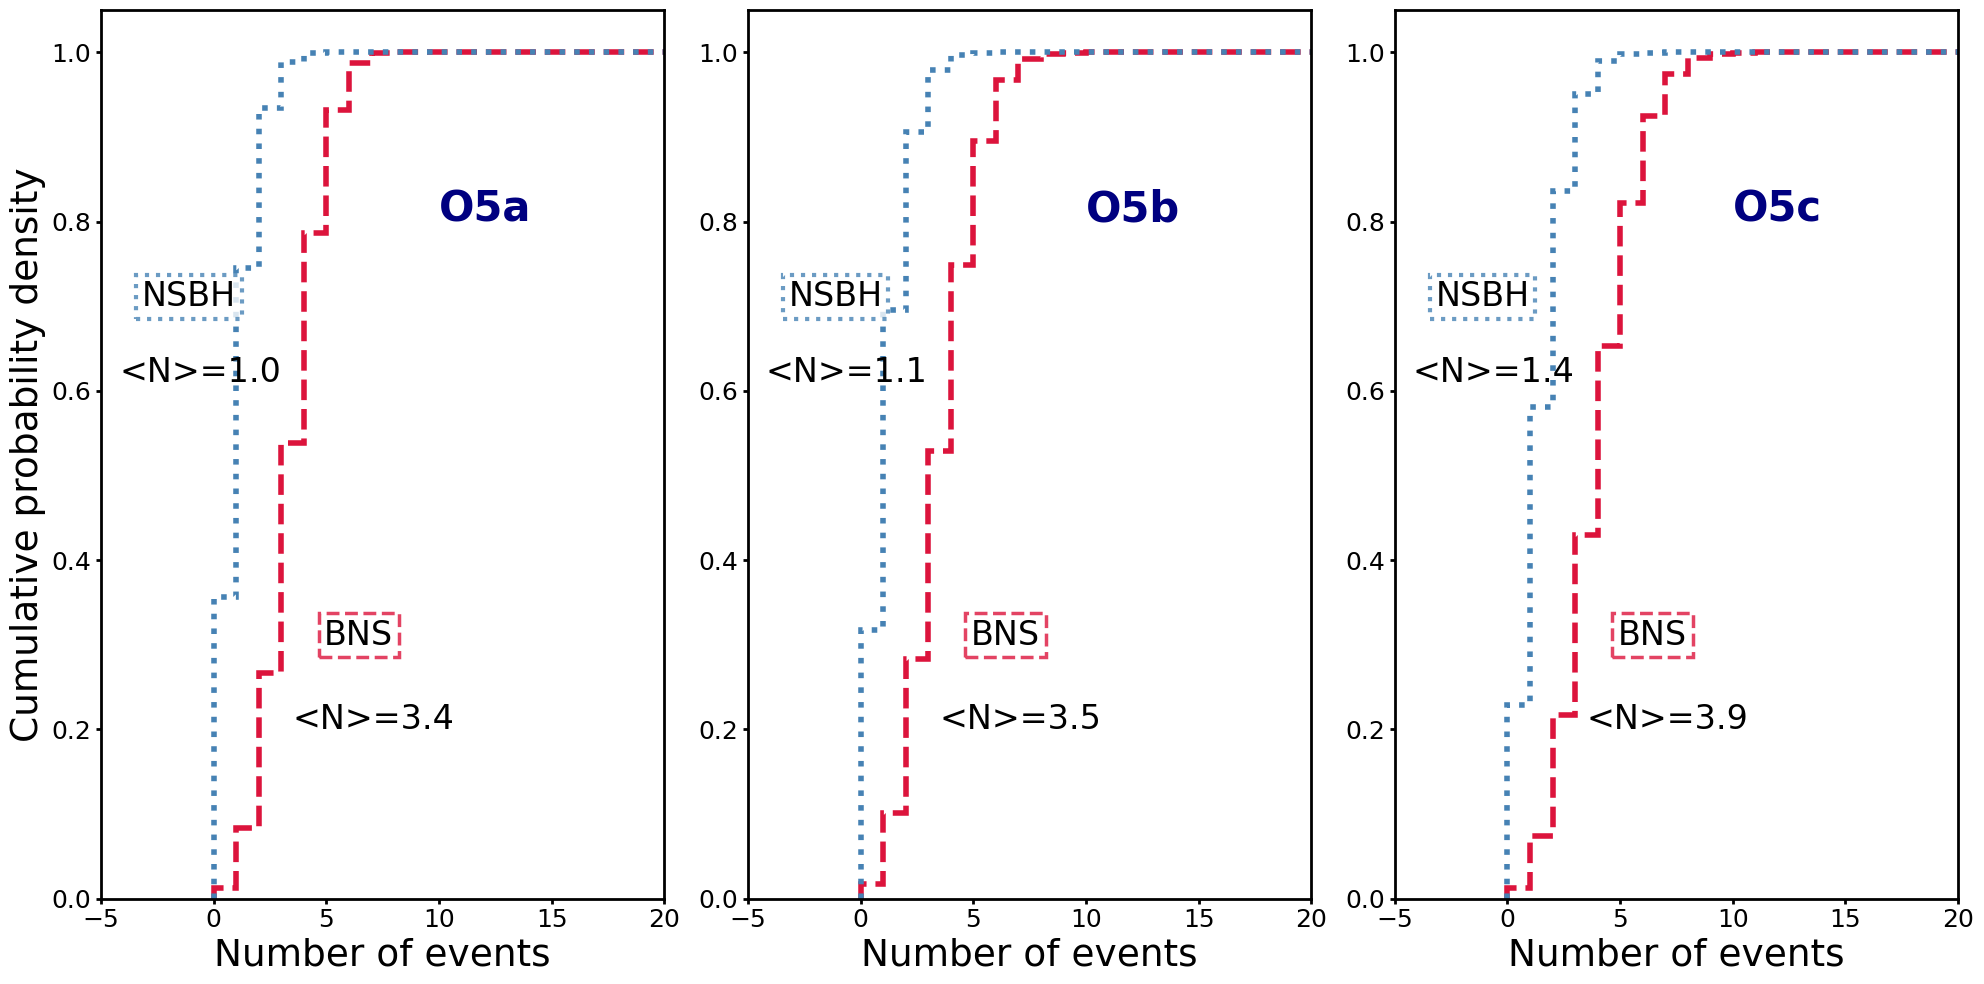

Vera C. Rubin KN detection horizon : 2187.8 Mpc
  (m_lim=25.7, M_abs=-16)

  Run : O5a
  BNS
    Mean   : 8.0
    Median : 8  (+0 / -0)  [90% CI]
  NSBH
    Mean   : 10.0
    Median : 10  (+0 / -0)  [90% CI]

  Run : O5b
  BNS
    Mean   : 13.0
    Median : 13  (+0 / -0)  [90% CI]
  NSBH
    Mean   : 15.7
    Median : 16  (+0 / -1)  [90% CI]

  Run : O5c
  BNS
    Mean   : 18.0
    Median : 18  (+0 / -0)  [90% CI]
  NSBH
    Mean   : 18.6
    Median : 19  (+0 / -2)  [90% CI]



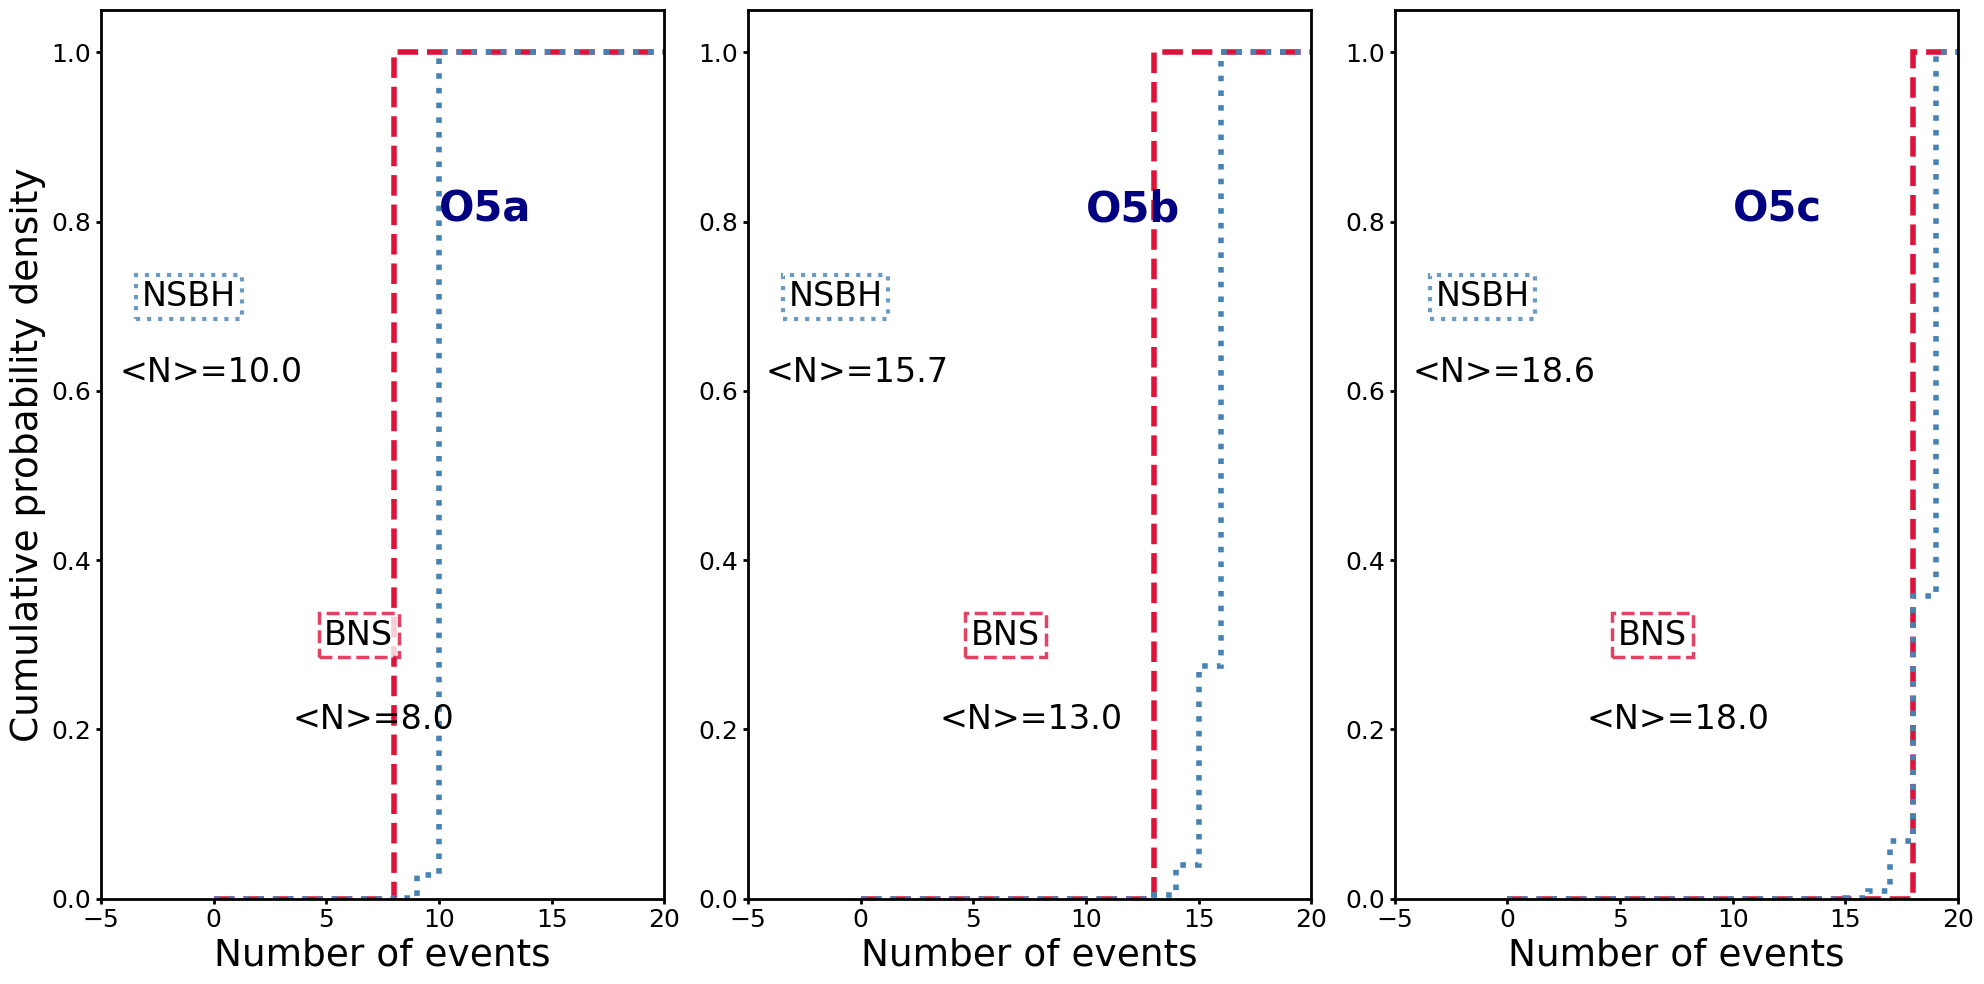

In [255]:
# Same TELESCOPES dict as the IR1 block above (GOTO/ZTF/Vera C. Rubin,
# reused as-is). O5 config is separate: three sub-runs (O5a/O5b/O5c, all
# HLV), each a ~1-year segment -- matching the T_obs=1 convention used for
# O5 throughout scripts/paper_plots/population_stats.py's own tables.
COMMON_O5 = dict(
    datapath="../../data/runs",
    run_names=["O5a", "O5b", "O5c"],
    model="fullpop",
    run_durations={"O5a": 1.0, "O5b": 1.0, "O5c": 1.0},
    ns_max_mass=3.0,
    n_realizations=100_000,
    seed=42,
    verbose=True,
)

for telescope, cfg in TELESCOPES.items():
    results, d_max = run_analysis(
        **COMMON_O5,
        **cfg,
        telescope_name=telescope,
    )
    plot_results(
        results,
        run_names=COMMON_O5["run_names"],
        telescope_name=telescope,
        outdir=None,
        show=True,
    )

###  Computes the Binary Neutron Star (BNS) inspiral range for observing runs O5 (a/b/c),

###  SNR=8 and a 1.4 solar mass binary system

In [256]:
# Run the analysis (prints a summary automatically)

path = Path("../../data/asd")
ifos = ["L1", "H1", "V1"]
run_names = ["O5a", "O5b", "O5c"]

calculator = BNSInspiralRangeCalculator(
    run_names=run_names,
    ifos=ifos,
    path=path,
    data_type="ASD",
)

## BNS inspiral range values

In [257]:
calculator.calculate_bns_range()



The BNS range in Run O5a,
with the Projected PSD



The BNS range in Run O5b,
with the Projected PSD



The BNS range in Run O5c,
with the Projected PSD





### Plot ASD sensitivity curves for O5 runs on a single figure

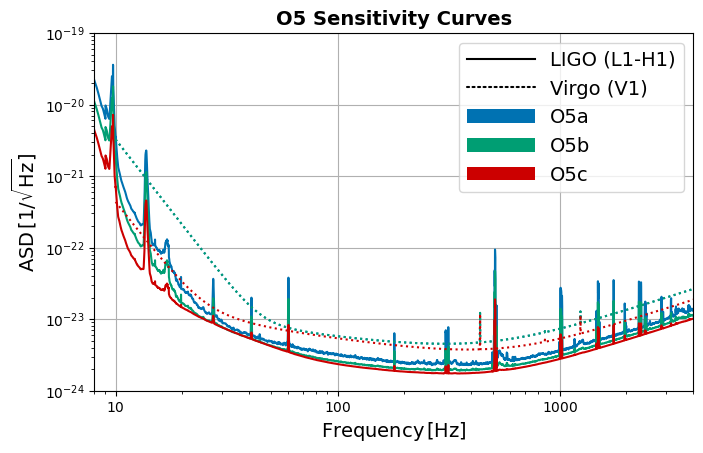

In [258]:
calculator.plot_sensitivity_curves(
    run_names=["O5a-HLV", "O5b-HLV", "O5c-HLV"],
    outdir=None,
)